<a href="https://colab.research.google.com/github/DRzaid-tech/MLREH2/blob/main/FLGPVSZaid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install scikit-optimize

In [ ]:
import pandas as pd
import datetime
import numpy as np
import random
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from skopt import BayesSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    make_scorer,
)
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
import warnings
Storage_Link='/content/drive/MyDrive/PHD/Federated/'


In [ ]:
def split_multiclass_dataset_ensure_all_classes(df, label_col, num_sub_dfs, fault_major_ratio=0.6, weight_strategy="dynamic"):
    """
    Splits a multi-class dataset into multiple sub-dataframes with realistic distributions,
    ensuring each sub-dataframe contains all classes and one class is the majority.

    Parameters:
        df (pd.DataFrame): The dataframe to split.
        label_col (str): The column name of the label.
        num_sub_dfs (int): Number of sub-dataframes to create.
        fault_major_ratio (float): The ratio of the majority class in a sub-dataframe.
        weight_strategy (str): "dynamic" for randomized weights, or "custom" for user-defined weights.

    Returns:
        list of pd.DataFrame: A list of sub-dataframes with specified distributions.
    """
    import random

    # Separate the dataframe by label
    class_groups = {label: group.copy() for label, group in df.groupby(label_col)}

    # Shuffle each class group
    for label in class_groups:
        class_groups[label] = class_groups[label].sample(frac=1, random_state=42).reset_index(drop=True)

    # Check if we have enough data for all classes in all sub-dataframes
    total_rows_per_df = len(df) // num_sub_dfs

    # Initialize the list of sub-dataframes
    sub_dfs = []

    for i in range(num_sub_dfs):
        # Identify all classes
        all_classes = list(class_groups.keys())
        if not all_classes:
            print("Warning: No classes left to assign.")
            break

        # Select a major class for this sub-dataframe
        major_class = all_classes[i % len(all_classes)]

        # Start creating the sub-dataframe
        sub_df = pd.DataFrame()

        # Ensure at least one row from each class
        for cls in all_classes:
            if len(class_groups[cls]) > 0:
                sub_df = pd.concat([sub_df, class_groups[cls].iloc[:1]])
                class_groups[cls] = class_groups[cls].iloc[1:]
            else:
                print(f"Warning: Not enough data for class {cls}.")

        # Allocate remaining rows
        remaining_rows = total_rows_per_df - len(sub_df)
        if remaining_rows > 0:
            major_size = min(len(class_groups[major_class]), int(remaining_rows * fault_major_ratio))
            major_size = max(major_size, 1)  # Ensure at least 1 row is selected for the major class

            sub_df = pd.concat([sub_df, class_groups[major_class].iloc[:major_size]])
            class_groups[major_class] = class_groups[major_class].iloc[major_size:]

            # Allocate rows for other classes based on weights
            remaining_classes = [cls for cls in all_classes if cls != major_class]
            remaining_rows = total_rows_per_df - len(sub_df)

            if weight_strategy == "dynamic":
                # Generate random weights for non-major classes
                weights = [random.uniform(0.1, 1.0) for _ in remaining_classes]
            elif weight_strategy == "custom":
                # Define custom weights for class distribution (can be adjusted)
                weights = [1.0 / len(remaining_classes) for _ in remaining_classes]  # Replace with custom weights
            else:
                raise ValueError("Invalid weight_strategy. Choose 'dynamic' or 'custom'.")

            # Normalize weights to sum to 1
            weights = [w / sum(weights) for w in weights]

            for cls, weight in zip(remaining_classes, weights):
                size_to_add = min(len(class_groups[cls]), max(int(remaining_rows * weight), 1))
                sub_df = pd.concat([sub_df, class_groups[cls].iloc[:size_to_add]])
                class_groups[cls] = class_groups[cls].iloc[size_to_add:]

        # Shuffle and reset index
        sub_df = sub_df.sample(frac=1, random_state=42).reset_index(drop=True)
        sub_dfs.append(sub_df)

        # Stop if any class runs out of rows
        if all(len(group) == 0 for group in class_groups.values()):
            print("Warning: Dataset exhausted. Cannot create more sub-dataframes.")
            break

    return sub_dfs


In [ ]:
# Function to process DataFrame and return training and testing sets
def process_and_split_dataframe(df, feature_names,target_column,  test_size=0.2, random_state=42,scaling=False,scaling_type='normal'):
    """Process the DataFrame and split into training and testing sets."""
    # Drop the target column and retain specified feature names
    df.dropna(inplace=True)
    X = df.drop([target_column], axis=1)
    X = X[feature_names]  # Reorder columns based on feature names

    # Extract the target column and convert to integer type
    y = df[target_column].astype(int)
    if y.dtype==object:
      y=pd.to_numeric(y,errors='coerce')
    if scaling==True:
      # Scale the data
      X_scaled=scale_data(X, scaling_type=scaling_type)
    else:
      X_scaled=X

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=random_state)

    return X_train, X_test, y_train, y_test

In [ ]:
def scale_data(data, scaling_type='standard'):
    """
    Scale the input data based on the user's choice of scaling type.

    Parameters:
    - data: numpy array or pandas DataFrame, input data to be scaled
    - scaling_type: str, type of scaling to be applied ('standard', 'normal', 'robust')

    Returns:
    - scaled_data: numpy array or pandas DataFrame, scaled data
    """
    feature_names=data.columns
    if scaling_type == 'standard':
        scaler = StandardScaler()
    elif scaling_type == 'normal':
        scaler = MinMaxScaler()
    elif scaling_type == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError("Invalid scaling_type. Choose from 'standard', 'normal', or 'robust'.")

    scaled_data = scaler.fit_transform(data)
    # Convert the scaled data back to DataFrame with proper column names
    X_scaled = pd.DataFrame(scaled_data, columns=feature_names)
    return X_scaled

In [ ]:
def getXY(df, feature_names,target_column, scaling=False,scaling_type='normal'):
    """Process the DataFrame and split into training and testing sets."""
    # Drop the target column and retain specified feature names
    X = df.drop([target_column], axis=1)
    X = X[feature_names]  # Reorder columns based on feature names

    # Extract the target column and convert to integer type
    # y = df[target_column].astype(int) # This line was causing the error
    y = pd.to_numeric(df[target_column], errors='coerce').astype(int)  # Convert to numeric, handle errors, then to int
    if scaling==True:
      # Scale the data
      X_scaled=scale_data(X, scaling_type=scaling_type)
    else:
      X_scaled=X

    return X_scaled, y

In [ ]:
def construct_datasets(df_f):
    # Clean data, avoiding in-place modifications for safety
    df_final = df_f.dropna().reset_index(drop=True)

    # Copy for naive dataset
    df_naive = df_f.copy()

    # Create binary dataset
    df_binary = df_f.copy()
    df_binary.loc[df_f['FaultType'] == 0, 'FaultType'] = 0
    df_binary.loc[df_f['FaultType'] > 0, 'FaultType'] = 1
    print("Unique values in df_binary['FaultType']:", df_binary['FaultType'].unique())

    # Create multi-fault dataset
    df_multi_fault = df_f.copy()
    df_multi_fault = df_multi_fault[df_final['FaultType'] > 0]
    print("Unique values in df_multi_fault['FaultType']:", df_multi_fault['FaultType'].unique())

    return df_naive, df_binary, df_multi_fault

In [ ]:
def readingDataFrame(percentage=1):
    random.seed(4321)
    #ZAID
    df_finalfully = pd.read_csv('/content/drive/MyDrive/PHD/classification_data.csv')
    #Hassan
    #df_finalfully = pd.read_csv('/content/drive/MyDrive/classification_data.csv')
    ln=int(np.floor(percentage*df_finalfully.shape[0]))
    df_final=df_finalfully.sample(n=ln, random_state=42)  # `random_state` for reproducibility
    return df_finalfully,df_final

# **Modify HERE**

In [ ]:
# Function to divide a DataFrame into `n` smaller DataFrames without duplicates
def divide_dataframe(df, n, random_state=None):
    """
    Divide a DataFrame into `n` smaller DataFrames with random samples and without duplicates.

    Parameters:
    - df (pd.DataFrame): The original DataFrame to divide.
    - n (int): The number of smaller DataFrames to create.
    - random_state (int, optional): Seed for reproducibility. Default is None.

    Returns:
    - List[pd.DataFrame]: List of `n` smaller DataFrames.
    """

    # Shuffle the DataFrame
    df_shuffled = df#.sample(frac=1, random_state=random_state).reset_index(drop=True)
    print(df_shuffled.shape)
    # Calculate the size of each smaller DataFrame
    chunk_size = int(np.ceil(len(df_shuffled) / n))

    # List to hold the smaller DataFrames
    smaller_dataframes = []

    # Create smaller DataFrames
    for i in range(n):
        start = i * chunk_size
        end = min(start + chunk_size, len(df_shuffled))
        smaller_df = df_shuffled[start:end].sample(n=15000, random_state=42)
        print(smaller_df.shape)
        smaller_dataframes.append(smaller_df)

    return smaller_dataframes

In [ ]:
 # Function to save smaller DataFrames to CSV files
def save_smaller_dfs_to_csv(smaller_dfs, file_prefix, directory=None):
    """
    Save each DataFrame in `smaller_dfs` to a separate CSV file.

    Parameters:
    - smaller_dfs (dict): Dictionary of smaller DataFrames to save.
    - file_prefix (str): Prefix for the output CSV file names.
    - directory (str, optional): Directory to save the CSV files. Default is current directory.
    """

    # If a directory is specified, create it if it doesn't exist
    if directory:
        os.makedirs(directory, exist_ok=True)  # Create the directory if it doesn't exist

    # Iterate over the smaller DataFrames and save each to a CSV file
    # for idx, df in smaller_dfs.items():
      # Display each of the smaller DataFrames
    for idx, df in enumerate(smaller_dfs):
        # print(f"DataFrame {idx + 1}:\n{dframe}\n")
        # Construct the file name with the prefix and index
        file_name = f"{file_prefix}_{idx + 1}.csv"
        file_path = os.path.join(directory if directory else ".", file_name)

        # Save the DataFrame to CSV
        df.to_csv(file_path, index=False)

    print("CSV files saved successfully.")

In [ ]:
#  Corrected function for training and evaluating MLP for classification
def train_and_evaluate_MLP_classification(
    X,
    y,
    i,
    test_size=0.2,
    random_state=42,
    hidden_layer_sizes=(30,),
    max_iter=10000,
    activation_functions=["relu"],
    # solvers=["adam"],
    layer_range=(1, 4),
    max_neurons_per_layer=100,
    # learning_rates=[0.00001,0.0001, 0.001, 0.01, 0.1],
    learning_rate_types=["adaptive"],
):
    """Train and evaluate a Multi-Layer Perceptron (MLP) model for classification."""
    results = []
    # for solver in solvers:
    if i==1:
      labels=["No-Fault", "Fault"]
      String='Fault Detection'
    else:
      String='Fault Detection'
      labels = [ 'Inverter Fault '#:1
                ,'Feedback Sensor Fault '
                ,'Grid Anomaly'#:3
                 ,
                          'Non-homogeneous partial shading'#:4
                 ,'Open circuit in PV array'#:5
                 ,
                           'MPPT/IPPT Controller Fault'#:6
                 ,'Boost Converter Controller Fault'#:7
               ]
        #   for activation in activation_functions:
    for learning_rate_type in tqdm(learning_rate_types):
              for num_layers in range(layer_range[0], layer_range[1] + 1):
                  for layer_size in range(3, max_neurons_per_layer + 1, 3):
                      # for learning_rate in learning_rates:
                          # Construct the hidden_layer_sizes tuple for the MLP model
                          layer_sizes = tuple([layer_size] * num_layers)

                          # Split the data into training and testing sets
                          X_train, X_test, y_train, y_test = train_test_split(
                              X, y, test_size=test_size, random_state=random_state
                          )
                          Common_Params={"X":X_train,"y":y_train,"train_sizes":np.linspace(0.1,1,5),
                       "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=0),"score_type": "both",
                       "n_jobs": 4,
                       "line_kw": {"marker": "o"},
                       "std_display_style": "fill_between",
                       "score_name": "Accuracy",}

                          # Create the MLP model for classification
                          mlp_model = MLPClassifier(
                              hidden_layer_sizes=layer_sizes,
                              max_iter=max_iter,
                              activation="relu",
                              solver="adam",
                              learning_rate=learning_rate_type,
                              # learning_rate_init=learning_rate,
                              random_state=random_state,
                          )

                          # Train the MLP model
                          mlp_model.fit(X_train, y_train)

                          # Predict on the test set
                          y_pred = mlp_model.predict(X_test)
                          #Added By ZAID
        #                   LearningCurveDisplay.from_estimator(mlp_model, **Common_Params)
        #                   plt.title('Learning Curve For Local The Global Architecture: '+String)
        #                   plt.grid(True)
        #                   samples = X_test.iloc[:2]
        #                   clf=mlp_model
        #                   predictions = clf.predict(samples)
        #     # #SHAP Explanation
        #     #               explainer = shap.KernelExplainer(clf.predict_proba, X_train)  # For probabilities (multi-class)
        #     #               shap_values = explainer.shap_values(samples)  # Use the two samples
        #     #               print(f"SHAP values shape: {np.array(shap_values).shape}")
        #     #               shap.plots.bar(shap_values)

        # #Confusion Matrix and Metrics
        #                   conf_matrix = confusion_matrix(y_test, y_pred, normalize='true')
        #                   conf_matrix2 = confusion_matrix(y_test, y_pred)
        #                   cm_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

        #                   plt.figure(figsize=(6, 6))
        #                   sns.heatmap(cm_df, annot=True, cmap="Blues", fmt=".3f", xticklabels=labels, yticklabels=labels)
        #                   plt.title(f"Confusion Matrix for Local Instance: ", fontsize=16)
        #                   plt.xlabel("Predicted", fontsize=16)
        #                   plt.ylabel("Actual", fontsize=16)
        #                   plt.xticks(fontsize=16)
        #                   plt.yticks(fontsize=16)
        #                   plt.show()
                          # Evaluate the model
                          accuracy = accuracy_score(y_test, y_pred)
                          f1 = f1_score(y_test, y_pred, average='weighted')
                          precision = precision_score(y_test, y_pred, average='weighted')
                          recall = recall_score(y_test, y_pred, average='weighted')

                          # Store results
                          results.append({
                              # "Activation": activation,
                              "Learning_Rate_Type": learning_rate_type,
                              "Num_layers": num_layers,
                              "Layer_size": layer_sizes,
                              # "Learning_rate": learning_rate,
                              "Max_iter": max_iter,
                              # "Solver": solver,
                              "Random_state": random_state,
                              "Accuracy": accuracy,
                              "F1-score": f1,
                              "Precision": precision,
                              "Recall": recall,
                          })

    # Create a DataFrame from the results
    df_results = pd.DataFrame(results)

    # Sort by accuracy and F1-score
    df_results_sorted = df_results.sort_values(by=["Accuracy", "F1-score"], ascending=[False, False])

    return df_results_sorted

In [ ]:
def FederatedLearningDataSetSplit(df,n=5,file_prefix="Client_df", directory="./Client_dfs"):
  smaller_dfs =divide_dataframe(df, n, random_state=42)
  save_smaller_dfs_to_csv(smaller_dfs, file_prefix=file_prefix, directory=directory)
  return smaller_dfs

In [ ]:
# def extractTopStructure(df_results_sorted,ind=0):
#   architecture=df_results_sorted['Layer_size'].iloc[ind]
#   Learning_rate=df_results_sorted['Learning_rate'].iloc[ind]
#   max_iter=df_results_sorted['Max_iter'].iloc[ind]
#   activation=df_results_sorted['Activation'].iloc[ind]
#   solver=df_results_sorted['Solver'].iloc[ind]
#   random_state=df_results_sorted['Random_state'].iloc[ind]
#   learning_rate_type=df_results_sorted['Learning_Rate_Type'].iloc[ind]
#   return architecture,Learning_rate,max_iter,activation,solver,random_state,learning_rate_type

def extractTopStructure(df_results_sorted,ind=0):
  architecture=df_results_sorted['Layer_size'].iloc[ind]
  # Learning_rate=df_results_sorted['Learning_rate'].iloc[ind]
  max_iter=df_results_sorted['Max_iter'].iloc[ind]
  # activation=df_results_sorted['Activation'].iloc[ind]
  # solver=df_results_sorted['Solver'].iloc[ind]
  random_state=df_results_sorted['Random_state'].iloc[ind]
  learning_rate_type=df_results_sorted['Learning_Rate_Type'].iloc[ind]
  return architecture,max_iter,random_state,learning_rate_type




In [ ]:
df_finalfully,df_final= readingDataFrame()
# df_final.drop('Time', axis=1, inplace=True)
# df_finalfully.drop('Time', axis=1, inplace=True)
df_final = pd.get_dummies(df_final, columns=['Mode'])
df_finalfully = pd.get_dummies(df_finalfully, columns=['Mode'])
df_finalfully.drop(['Mode_L'], axis=1, inplace=True)
df_final.drop(['Mode_L'], axis=1, inplace=True)
print(df_final.columns)
dfnaivefully,dfBinaryfully,dfmultiFaultfully=construct_datasets(df_final)
feature_names=list(dfnaivefully.columns)
feature_names.remove('FaultType')
feature_names

Index(['Time', 'Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic', 'va', 'vb', 'vc', 'Iabc',
       'If', 'Vabc', 'Vf', 'FaultType', 'Mode_M'],
      dtype='object')
Unique values in df_binary['FaultType']: [1 0]


<ipython-input-77-2800ef9250cb>:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_multi_fault = df_multi_fault[df_final['FaultType'] > 0]


Unique values in df_multi_fault['FaultType']: [4 6 1 2 7 3 0 5]


['Time',
 'Ipv',
 'Vpv',
 'Vdc',
 'ia',
 'ib',
 'ic',
 'va',
 'vb',
 'vc',
 'Iabc',
 'If',
 'Vabc',
 'Vf',
 'Mode_M']

['Non-homogeneous partial shading' 'MPPT/IPPT Controller Fault'
 'Inverter Fault ' 'Open circuit in PV array' 'No-Fault'
 'Feedback Sensor Fault ' 'Boost Converter Controller Fault'
 'Grid Anomaly']
FaultType
MPPT/IPPT Controller Fault          288030
Boost Converter Controller Fault    288030
Non-homogeneous partial shading     288028
Open circuit in PV array            287029
Feedback Sensor Fault               286143
No-Fault                            284729
Inverter Fault                      268027
Grid Anomaly                        173464
Name: count, dtype: int64
['Non-homogeneous partial shading' 'MPPT/IPPT Controller Fault'
 'Inverter Fault ' 'Feedback Sensor Fault '
 'Boost Converter Controller Fault' 'Grid Anomaly' nan
 'Open circuit in PV array']
FaultType
MPPT/IPPT Controller Fault          250290
Non-homogeneous partial shading     250181
Boost Converter Controller Fault    249975
Open circuit in PV array            249186
Feedback Sensor Fault               248272
Inve

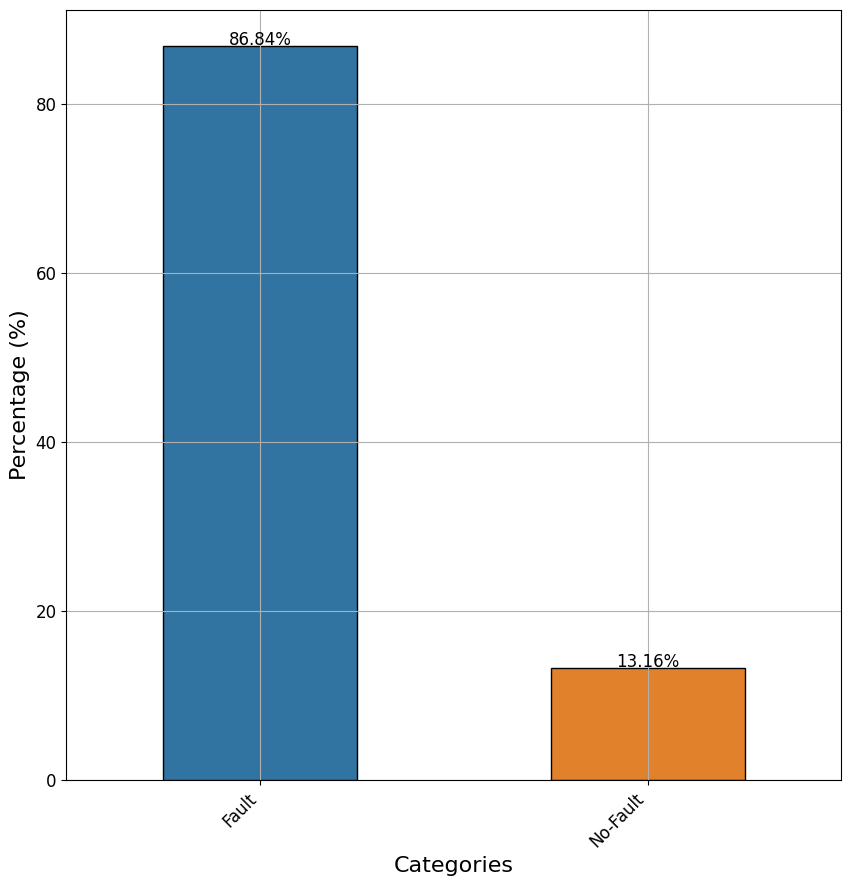

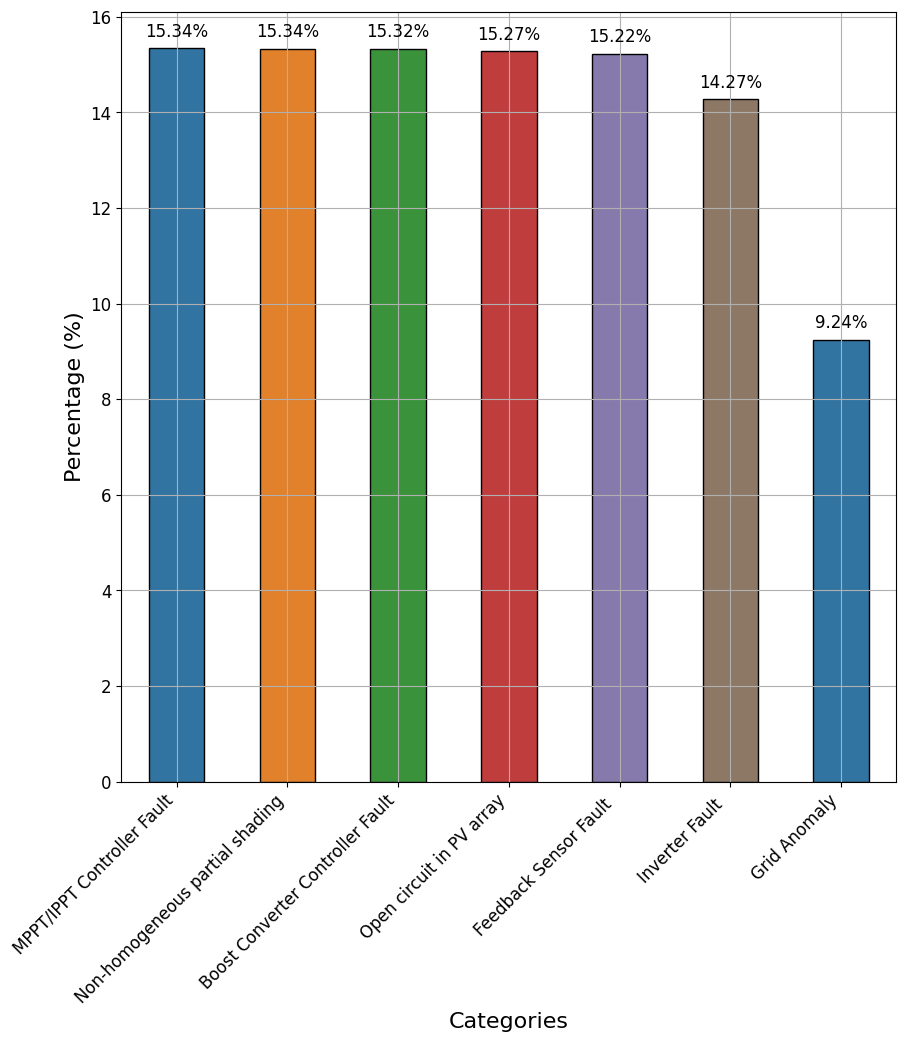

In [ ]:
def plot_bar_chart(df, title='Type Distribution', figsize=(10, 10), text_size=16):
    # Ensure 'FaultType' column has expected categories
    # Replace 'expected_categories' with your actual categories if different
    expected_categories = df['FaultType'].unique()  # Get unique values from the dataframe
    category_counts = df['FaultType'].value_counts()
    print(expected_categories,category_counts)
    # Filter and normalize category counts based on expected categories
    category_counts = category_counts[category_counts.index.isin(expected_categories)]
    category_counts = (category_counts / np.sum(category_counts)) * 100

    plt.figure(figsize=figsize)
    cmap = ["#3274a1", "#e1812c", "#3a923a", "#c03d3e", "#857aab", "#8d7866"]

    # Plot the bar chart
    category_counts.plot(kind='bar', color=cmap, edgecolor='black')

    # Add Labels and title
    plt.xlabel('Categories', fontsize=text_size)
    plt.ylabel('Percentage (%)', fontsize=text_size)
    # plt.title('Type Distribution', fontsize=text_size)
    plt.xticks(rotation=45, ha='right', fontsize=text_size-4)
    plt.yticks(fontsize=text_size-4)
    # Show percentage on bars
    for i, v in enumerate(category_counts):
        plt.text(i, v + 0.25, f'{v:.2f}%', ha='center', fontsize=text_size-4)
    plt.grid('on')




multi_faults = {   1: 'Inverter Fault ', 2:'Feedback Sensor Fault ',3:'Grid Anomaly',4:'Non-homogeneous partial shading',
      5:'Open circuit in PV array',6:'MPPT/IPPT Controller Fault',7:'Boost Converter Controller Fault'}

faults = { 0:"No-Fault",   1: 'Inverter Fault ', 2:'Feedback Sensor Fault ',3:'Grid Anomaly',4:'Non-homogeneous partial shading',
      5:'Open circuit in PV array',6:'MPPT/IPPT Controller Fault',7:'Boost Converter Controller Fault'}

bin_faults = { 0:"No-Fault", 1:"Fault"}

dfnaivefully["FaultType"]= dfnaivefully["FaultType"].map(faults)
print(dfnaivefully["FaultType"].unique())
print(dfnaivefully['FaultType'].value_counts())

dfmultiFaultfully["FaultType"] =dfmultiFaultfully["FaultType"].map(multi_faults)
print(dfmultiFaultfully["FaultType"].unique())
print(dfmultiFaultfully['FaultType'].value_counts())


dfBinaryfully["FaultType"] =dfBinaryfully["FaultType"].map(bin_faults)
print(dfBinaryfully["FaultType"].unique())
print(dfBinaryfully['FaultType'].value_counts())


fault_labels = [
    'No-Fault',
    'Inverter Fault ',
    'Feedback Sensor Fault ',
    'Grid Anomaly',
    'Non-homogeneous partial shading',   # PV Array Mismatch (10 to 20% nonhomogeneous partial shading)
    'Open circuit in PV array',#PV Array Mismatch (15% open circuit in PV array)
    'MPPT/IPPT Controller Fault',
    'Boost Converter Controller Fault'
]
fault_map = {"No-Fault": 0, "Fault": 1}
multiFaultsList =  ['Inverter Fault ',
    'Feedback Sensor Fault ',
    'Grid Anomaly',
    'Non-homogeneous partial shading',   # PV Array Mismatch (10 to 20% nonhomogeneous partial shading)
    'Open circuit in PV array',#PV Array Mismatch (15% open circuit in PV array)
    'MPPT/IPPT Controller Fault',
    'Boost Converter Controller Fault'
]

fault_list = ["No-Fault", "Fault"]

plot_bar_chart(dfBinaryfully)
# plot_bar_chart(dfnaivefully)
plot_bar_chart(dfmultiFaultfully)

In [ ]:
dfBinaryfully

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,FaultType,Mode_M
1235044,7.866029,1.821136,87.432861,145.312500,-0.558106,0.315552,0.195552,155.538483,-85.610657,-66.922251,0.532815,50.114684,155.259798,49.998691,Fault,True
1663183,7.575580,1.385956,101.885986,144.140625,0.475829,-0.174561,-0.368413,-147.739258,34.945831,116.630758,0.490148,49.947292,156.123729,50.001426,Fault,False
308793,2.406237,1.464478,101.873779,143.847656,0.395263,-0.281982,-0.113286,-133.093109,135.865631,-3.728841,0.433607,50.732185,154.815451,49.996463,Fault,False
548320,13.456479,1.919525,8.026123,5.273438,-0.020997,-0.053711,0.081416,-117.398224,147.763367,-28.818156,0.035815,48.467589,155.320173,49.999416,Fault,True
406063,12.132257,1.466370,101.812744,142.089844,0.294555,0.530396,-0.798101,-33.258209,-113.504639,148.084819,0.431725,50.147351,154.940079,50.005800,Fault,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003274,12.781155,1.534485,101.727295,141.503906,0.442260,-0.255127,-0.187139,-154.501801,90.179291,65.540009,0.447637,49.855108,155.522363,49.997112,Fault,False
1570006,12.658803,2.475800,80.902100,80.859375,1.019652,-0.496826,-0.603398,-146.714630,34.089966,115.348969,1.045341,50.102486,155.244994,50.000959,Fault,True
732180,3.729260,2.534454,84.368896,148.535156,-0.417115,-0.335693,0.719233,84.947662,72.893219,-154.662526,0.720111,49.965192,155.757640,50.003344,Fault,True
110268,11.025710,1.613007,101.019287,142.968750,-0.450685,0.020142,0.356685,137.529144,-6.871033,-130.609894,0.477367,49.956113,155.281013,49.995530,No-Fault,False


In [ ]:
  Fault_map = {"No-Fault": 0, "Fault": 1}
  Inverse_Fault_map={0:'No_Fault',1:'Fault'}
  #dfBinaryfully["FaultType"] = dfBinaryfully["FaultType"].map(fault_map)
  Inverse_multi_faults = { 'Inverter Fault ':1,'Feedback Sensor Fault ':2,'Grid Anomaly':3,
                          'Non-homogeneous partial shading':4,'Open circuit in PV array':5,
                           'MPPT/IPPT Controller Fault':6,'Boost Converter Controller Fault':7
                         }

  inverseNaive_faults = { "No-Fault":0, 'Inverter Fault ':1, 'Feedback Sensor Fault ':2,
                         'Grid Anomaly':3,'Non-homogeneous partial shading':4,'Open circuit in PV array':5,
                          'MPPT/IPPT Controller Fault':6,'Boost Converter Controller Fault':7
  }
  inverse_multiF={'Non-homogeneous partial shading':4, 'MPPT/IPPT Controller Fault':6,
       'Inverter Fault ':1, 'Feedback Sensor Fault ':2,
       'Boost Converter Controller Fault':7, 'Grid Anomaly':3,
       'Open circuit in PV array':5}

  #  Selective
  dfnaivefully["FaultType"] =dfnaivefully["FaultType"].map(inverseNaive_faults)
  dfBinaryfully["FaultType"] = dfBinaryfully["FaultType"].map(Fault_map)
  dfmultiFaultfully.dropna(inplace=True)
  dfmultiFaultfully["FaultType"] =dfmultiFaultfully["FaultType"].map(inverse_multiF)

In [ ]:
dfmultiFaultfully["FaultType"].unique()

array([4, 6, 1, 2, 7, 3, 5])

In [ ]:
# dfBinaryfully["FaultType"] = dfBinaryfully["FaultType"].map(Inverse_Fault_map)
dfBinaryfully#[dfBinaryfully.FaultType==1]

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,FaultType,Mode_M
1235044,7.866029,1.821136,87.432861,145.312500,-0.558106,0.315552,0.195552,155.538483,-85.610657,-66.922251,0.532815,50.114684,155.259798,49.998691,1,True
1663183,7.575580,1.385956,101.885986,144.140625,0.475829,-0.174561,-0.368413,-147.739258,34.945831,116.630758,0.490148,49.947292,156.123729,50.001426,1,False
308793,2.406237,1.464478,101.873779,143.847656,0.395263,-0.281982,-0.113286,-133.093109,135.865631,-3.728841,0.433607,50.732185,154.815451,49.996463,1,False
548320,13.456479,1.919525,8.026123,5.273438,-0.020997,-0.053711,0.081416,-117.398224,147.763367,-28.818156,0.035815,48.467589,155.320173,49.999416,1,True
406063,12.132257,1.466370,101.812744,142.089844,0.294555,0.530396,-0.798101,-33.258209,-113.504639,148.084819,0.431725,50.147351,154.940079,50.005800,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003274,12.781155,1.534485,101.727295,141.503906,0.442260,-0.255127,-0.187139,-154.501801,90.179291,65.540009,0.447637,49.855108,155.522363,49.997112,1,False
1570006,12.658803,2.475800,80.902100,80.859375,1.019652,-0.496826,-0.603398,-146.714630,34.089966,115.348969,1.045341,50.102486,155.244994,50.000959,1,True
732180,3.729260,2.534454,84.368896,148.535156,-0.417115,-0.335693,0.719233,84.947662,72.893219,-154.662526,0.720111,49.965192,155.757640,50.003344,1,True
110268,11.025710,1.613007,101.019287,142.968750,-0.450685,0.020142,0.356685,137.529144,-6.871033,-130.609894,0.477367,49.956113,155.281013,49.995530,0,False


In [ ]:
# # feature_names.remove('Time')
# import seaborn as sns
# for feature in feature_names:
#   print(feature)
#   plt.figure(figsize=(12,4))
#   sns.lineplot(data=dfBinaryfully[dfBinaryfully.FaultType==0].sample(n=10000),x='Time',y=feature)
#   plt.xticks(fontsize=14)
#   plt.yticks(fontsize=14)
#   plt.grid()
#   plt.ylabel(feature,fontsize=16)
#   plt.xlabel('Time',fontsize=16)
#   plt.figure(figsize=(12,4))
#   sns.lineplot(data=dfBinaryfully[dfBinaryfully.FaultType==1].sample(n=10000),x='Time',y=feature,color='red')
#   plt.ylabel(feature,fontsize=16)
#   plt.xticks(fontsize=14)
#   plt.yticks(fontsize=14)
#   plt.xlabel('Time',fontsize=16)
#   plt.grid()
#   plt.show()

In [ ]:
# Function for hyperparameter tuning for MLPClassifier with BayesSearchCV
# import itertools
def tune_mlp_classification_bayes(
    X,
    y,
    # test_size=0.2,
    random_state=42,
    hidden_layer_range=(1, 3),
    max_neurons_per_layer=100,  # Maximum number of neurons per layer
    max_iter=7000,  # Maximum iterations
    activation_functions=["relu"],
    learning_rates=[0.000001,0.00001,0.0001, 0.001, 0.01, 0.1],  # Constrain learning rates
    learning_rate_types=["constant", "adaptive"],
    solvers=["adam"],
    n_iter=100,  # Number of iterations for BayesSearchCV
):
    """Hyperparameter tuning for MLPClassifier with BayesSearchCV for classification tasks."""
    # Define a specific set of hidden layer configurations
    # Create specific configurations with exact neuron counts
    # Define a list of possible hidden layer configurations (1 to 2 layers)
    # # These are specific, discrete tuples, avoiding ambiguity with ranges
    # hidden_layer_options = [
    #     (x,) for x in range(10, 101, 10)  # 1 hidden layer with 10 to 100 neurons
    # ] + [
    #     (x, y) for x, y in itertools.product(range(10, 101, 20), repeat=2)  # 2 hidden layers with varying sizes
    # ]

    # Define the parameter space for Bayesian optimization
    search_space = {
          "hidden_layer_sizes":Integer(5, max_neurons_per_layer),
          # Categorical(hidden_layer_options),
          # hidden_layer_options ,
          # Integer(5, max_neurons_per_layer),
          #  [(Integer(5, max_neurons_per_layer),Integer(5, max_neurons_per_layer))],
          # Categorical([(10, 10), (20, 20), (30, 30), (40, 40), (50, 50)]),
          # Categorical([(x, y) for x in range(10, 101, 30) for y in range(10, 101, 30)]),
          # Number of neurons per layer: Integer(5, max_neurons_per_layer), )
        "activation":Categorical(activation_functions),  # Activation functions
        "solver": Categorical(solvers),  # Solvers
        "learning_rate": Categorical(learning_rate_types),  # Learning rate types
        "learning_rate_init": Real(min(learning_rates), max(learning_rates), prior="log-uniform"),  # Initial learning rate
        "max_iter": Integer(5000, max_iter),  # Maximum iterations
    }

    # MLPClassifier with scoring based on accuracy
    model = MLPClassifier(random_state=random_state)
    scoring = "accuracy"  # Scoring function for BayesSearchCV

    # Set up BayesSearchCV for Bayesian optimization
    bayes_search = BayesSearchCV(
        model,
        search_space,
        n_iter=n_iter,
        scoring=scoring,
        n_jobs=-1,
        cv=3,
        verbose=1,
        random_state=random_state,
    )

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Perform the Bayesian optimization with error handling
    try:
        bayes_search.fit(X_train, y_train)
    except ValueError as e:
        raise ValueError(f"Error during Bayesian optimization: {e}")

    # Test the best model
    best_model = bayes_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Evaluate the best model with multiple metrics for classification
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    # Display results
    print(f"Best Model: {best_model}")
    print(f"Test Accuracy: {accuracy:.3f}, F1-score: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

    # Return the Bayesian search object and classification metrics
    return bayes_search

In [ ]:
!pip install lime

In [ ]:
# import lime
# import lime.lime_tabular

import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report
# def iteratingMLP(X_train, X_test, y_train, y_test, architecture,Learning_rate,max_iter,activation,solver,random_state,learning_rate_type):
#     # MLPClassifier with scoring based on accuracy
#     model = MLPClassifier(random_state=random_state,hidden_layer_sizes=architecture,activation=activation,solver=solver,learning_rate_init=Learning_rate,learning_rate=learning_rate_type)
#     # Split the data into training and testing sets
#     # X_train, X_test, y_train, y_test = train_test_split(
#         # X, y, test_size=test_size, random_state=random_state)

#     # Perform the Bayesian optimization with error handling
#     try:
#         model.fit(X_train, y_train)
#     except ValueError as e:
#         raise ValueError(f"Error during fitting: {e}")

#     # Test the best model
#     y_pred = model.predict(X_test)

#     # Evaluate the best model with multiple metrics for classification
#     accuracy = accuracy_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred, average='weighted')
#     precision = precision_score(y_test, y_pred, average='weighted')
#     recall = recall_score(y_test, y_pred, average='weighted')

#     # Display results
#     # print(f"Best Model: {best_model}")
#     print(f"Test Accuracy: {accuracy:.3f}, F1-score: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")


def iteratingMLP(X_train, X_test, y_train, y_test, architecture,max_iter,random_state,learning_rate_type):
    # MLPClassifier with scoring based on accuracy
    model = MLPClassifier(random_state=random_state,hidden_layer_sizes=architecture,learning_rate=learning_rate_type)
    # Split the data into training and testing sets
    # X_train, X_test, y_train, y_test = train_test_split(
        # X, y, test_size=test_size, random_state=random_state)

    # Perform the Bayesian optimization with error handling
    try:
        model.fit(X_train, y_train)
    except ValueError as e:
        raise ValueError(f"Error during fitting: {e}")
    explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns.values.tolist(),
                                                  class_names=list(X_test.columns), verbose=True, mode='classification')
    # Test the best model
    y_pred = model.predict(X_test)
    j=12
    exp = explainer.explain_instance(X_test.values[j], model.predict, num_features=6)
    # Evaluate the best model with multiple metrics for classification
    accuracy = accuracy_score(y_test, y_pred)
    if len(np.unique(y_test))>2:
      f1 = f1_score(y_test, y_pred, average='weighted')
      precision = precision_score(y_test, y_pred, average='weighted')
      recall = recall_score(y_test, y_pred, average='weighted')
    else:
      f1 = f1_score(y_test, y_pred, average='binary')
      precision = precision_score(y_test, y_pred, average='binary')
      recall = recall_score(y_test, y_pred, average='binary')

    # Display results
    # print(f"Best Model: {best_model}")
    print(f"Test Accuracy: {accuracy:.3f}, F1-score: {f1:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}")

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# df_results_sorted_binary= train_and_evaluate_MLP_classification(X_train,y_train,i=1)
# df_results_sorted_binary

In [ ]:
# architecture,max_iter,random_state,learning_rate_type=extractTopStructure(df_results_sorted_binary)
# df_results_sorted_binary.to_csv(Storage_Link+'Binary.csv', index=False)
# print('--------------------------------------------------------------------')
# iteratingMLP(X_train, X_test, y_train, y_test, architecture,max_iter,random_state,learning_rate_type)
# df_results_sorted_binary

In [ ]:
df_results_sorted_binary=pd.read_csv(Storage_Link+'Binary.csv')
df_results_sorted_binary

,Learning_Rate_Type,Num_layers,Layer_size,Max_iter,Random_state,Accuracy,F1-score,Precision,Recall
0,adaptive,1,"(45,)",10000,42,0.976250,0.976203,0.976162,0.976250
1,adaptive,2,"(72, 72)",10000,42,0.975625,0.975880,0.976315,0.975625
2,adaptive,1,"(48,)",10000,42,0.974375,0.974247,0.974159,0.974375
3,adaptive,1,"(81,)",10000,42,0.973750,0.973750,0.973750,0.973750
4,adaptive,1,"(90,)",10000,42,0.973125,0.972769,0.972684,0.973125
...,...,...,...,...,...,...,...,...,...
127,adaptive,4,"(3, 3, 3, 3)",10000,42,0.947500,0.948837,0.951172,0.947500
128,adaptive,4,"(54, 54, 54, 54)",10000,42,0.945625,0.943291,0.943380,0.945625
129,adaptive,2,"(3, 3)",10000,42,0.933750,0.932372,0.931554,0.933750
130,adaptive,1,"(6,)",10000,42,0.933125,0.931511,0.930644,0.933125


In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=200000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# architecture,max_iter,random_state,learning_rate_type=extractTopStructure(df_results_sorted_binary,ind=0)
# print(architecture,max_iter,random_state,learning_rate_type)
# architecture=(87,87)
# max_iter=100
# iteratingMLP(X_train, X_test, y_train, y_test, architecture,max_iter,random_state,learning_rate_type)
# print(architecture,max_iter,random_state,learning_rate_type)

In [ ]:
# tuple(architecture)

In [ ]:
# architecture

In [ ]:
# for ind in range(1,11):
#   print(ind, end="")
#   architecture,max_iter,random_state,learning_rate_type=extractTopStructure(df_results_sorted_binary,ind=ind)
#   max_iter=1000
#   architecture=[72,72]
#   iteratingMLP(X_train, X_test, y_train, y_test, [72,72],max_iter,random_state,learning_rate_type)

In [ ]:
# dfBinaryfully.sample(n=5000, random_state=42).to_csv(Storage_Link+'binarySample.csv',index=False)

In [ ]:
# df_results_sorted_binary

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfmultiFaultfully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.5, random_state=42,scaling=True,scaling_type='standard')
# bayes_search= tune_mlp_classification_bayes(X_train,y_train-1)

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfnaivefully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.5, random_state=42,scaling=True,scaling_type='standard')
# bayes_search= tune_mlp_classification_bayes(X_train,y_train)

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfnaivefully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# df_results_sorted_Naive= train_and_evaluate_MLP_classification(X_train,y_train)
# df_results_sorted_Naive.to_csv(Stortage_Link+'Naive.csv', index=False)
# print('--------------------------------------------------------------------')
# df_results_sorted_Naive

In [ ]:
# extractTopStructure(df_results_sorted_Naive,ind=0)
# architectureN,max_iterN,random_stateN,learning_rate_typeN=extractTopStructure(df_results_sorted_Naive,ind=0)
# df_results_sorted_Naive.to_csv(Stortage_Link+'Naive.csv', index=False)
# print('--------------------------------------------------------------------')
# df_results_sorted_Naive

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfnaivefully.sample(n=100000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# architecture,max_iter,random_state,learning_rate_type=extractTopStructure(df_results_sorted_Naive,ind=0)
# iteratingMLP(X_train, X_test, y_train, y_test, architecture,max_iter,random_state,learning_rate_type)

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfmultiFaultfully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# df_results_sorted_MultiFault= train_and_evaluate_MLP_classification(X_train,y_train,i=2)
# architecture,max_iter,random_state,learning_rate_type=extractTopStructure(df_results_sorted_MultiFault)

# df_results_sorted_MultiFault.to_csv(Storage_Link+'MultiFault.csv', index=False)
# print('--------------------------------------------------------------------')
# df_results_sorted_MultiFault

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfmultiFaultfully.sample(n=100000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# architecture,max_iter,random_state,learning_rate_type=extractTopStructure(df_results_sorted_MultiFault,ind=0)
# iteratingMLP(X_train, X_test, y_train, y_test, architecture,max_iter,random_state,learning_rate_type)

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=3000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=False,scaling_type='normal')
# df_results_sorted_binary= train_and_evaluate_MLP_classification(X_train,y_train)
# architectureB,Learning_rateB,max_iterB,activationB,solverB,random_stateB,learning_rate_typeB=extractTopStructure(df_results_sorted_binary)
# print("Binary:",architectureB,Learning_rateB,max_iterB,activationB,solverB,random_stateB,learning_rate_typeB)
# df_results_sorted_MultiFault.to_csv('/content/drive/MyDrive/Binary.csv', index=False)
# print('--------------------------------------------------------------------')
# print('--------------------------------------------------------------------')
# print(df_results_sorted_Binary)
# print('--------------------------------------------------------------------')
# print('--------------------------------------------------------------------')
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfmultiFaultfully.sample(n=3000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=False,scaling_type='normal')
# df_results_sorted_MultiFault= train_and_evaluate_MLP_classification(X_train,y_train)
# architectureM,Learning_rateM,max_iterM,activationM,solverM,random_stateM,learning_rate_typeM=extractTopStructure(df_results_sorted_MultiFault)
# print('Faults:', architectureM,Learning_rateM,max_iterM,activationM,solverM,random_stateM,learning_rate_typeM)
# df_results_sorted_MultiFault.to_csv('/content/drive/MyDrive/MultiFault.csv', index=False)
# print('--------------------------------------------------------------------')
# df_results_sorted_MultiFault
# print('--------------------------------------------------------------------')
# print('--------------------------------------------------------------------')
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfnaivefully.sample(n=3000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=False,scaling_type='normal')
# df_results_sorted_Naive= train_and_evaluate_MLP_classification(X_train,y_train)
# architectureN,Learning_rateN,max_iterN,activationN,solverN,random_stateN,learning_rate_typeN=extractTopStructure(df_results_sorted_Naive)
# print('Naive:', architectureN,Learning_rateN,max_iterN,activationN,solverN,random_stateN,learning_rate_typeN)
# df_results_sorted_Naive.to_csv('/content/drive/MyDrive/Naive.csv', index=False)
# print('--------------------------------------------------------------------')
# df_results_sorted_Naive

In [ ]:
# # print("Model","architecture","Learning_rate","max_iter","activation","solver","random_state","learning_rate_type")
# # print("Binary:",architectureB,Learning_rateB,max_iterB,activationB,solverB,random_stateB,learning_rate_typeB)
# # print('Faults:', architectureM,Learning_rateM,max_iterM,activationM,solverM,random_stateM,learning_rate_typeM)
# # print('Naive:', architectureN,Learning_rateN,max_iterN,activationN,solverN,random_stateN,learning_rate_typeN)

# print("Model","architecture","Learning_rate","max_iter","activation","solver","random_state","learning_rate_type")
# #print("Binary:",architectureB,max_iterB,random_stateB,learning_rate_typeB)
# print('Faults:', architectureM,max_iterM,random_stateM,learning_rate_typeM)
# #print('Naive:', architectureN,max_iterN,random_stateN,learning_rate_typeN)

In [ ]:
# df_results_sorted

In [ ]:
# Function for Grid hyperparameter tuning for classification with different solvers
def tune_mlp_classificationGrid(
    X_train, X_test, y_train, y_test,
    test_size=0.2,
    random_state=42,
    hidden_layer_range=(1, 3),
    max_neurons_per_layer=30,
    activation_functions=["relu"],
    #  activation_functions=["relu", "tanh"],
    learning_rates=[0.00001,0.0001, 0.001, 0.01, 0.1],
    # learning_rate_types=["constant", "adaptive","invscaling"],
     learning_rate_types=[ "adaptive","invscaling"],
    solvers=["adam"],  # List of solvers
    # solvers=["adam", "sgd", "lbfgs"],  # List of solvers
):
    """
    Hyperparameter tuning for MLPClassifier with different solvers using GridSearchCV.
    """
    # Construct the parameter grid
    param_grid = {
        "hidden_layer_sizes": [
            tuple(range(size, 0, -1))[:len(hidden_layer_range)] for size in range(max_neurons_per_layer, 10, -10)
        ],
        "activation": activation_functions,
        "solver": solvers,  # Test different solvers
        "learning_rate": learning_rate_types,
        "learning_rate_init": learning_rates,
        "max_iter": [1000],
    }

    # MLPClassifier with scoring based on accuracy
    model = MLPClassifier(random_state=random_state)
    scoring = make_scorer(accuracy_score)  # Accuracy for GridSearchCV

    # Set up GridSearchCV
    grid_search = GridSearchCV(
        model,
        param_grid,
        scoring=scoring,
        n_jobs=-1,
        cv=3,
        verbose=1,
    )

    # Split the data into training and testing sets
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # Perform grid search
    grid_search.fit(X_train, y_train)

    # Test the best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Evaluate the best model
    accuracy = accuracy_score(y_test, y_pred)
    if len(np.unique(y_test))>2:
      f1 = f1_score(y_test, y_pred, average="weighted")
    else:
      f1 = f1_score(y_test, y_pred, average="binary")

    print(f"Test Accuracy: {accuracy:.3f}, Test F1-score: {f1:.3f}")

    return grid_search


In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=2000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# df_results_sorted_binary= train_and_evaluate_MLP_classification(X_train,y_train)
# architecture,Learning_rate,max_iter,activation,solver,random_state,learning_rate_type=extractTopStructure(df_results_sorted_binary)
# df_results_sorted_binary.to_csv('/content/drive/MyDrive/Binary.csv', index=False)
# print('--------------------------------------------------------------------')
# df_results_sorted_binary

In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='normal')
# grid_search= tune_mlp_classificationGrid(X_train, X_test, y_train, y_test)
# # Get all parameters from the best model
# # Retrieve the best estimator
# best_model = grid_search.best_estimator_
# model_params = best_model.get_params()  # Retrieves all parameters of the best model
# print("Best model parameters:", model_params)

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


def tune_mlp_classificationBayes(
    X_train,
    X_test,
    y_train,
    y_test,
    random_state=42,
    hidden_layer_range=(1, 3),
    max_neurons_per_layer=100,
    activation_functions=["relu", "tanh"],
    learning_rates=[0.0001, 0.001, 0.01],
    learning_rate_types=["constant", "adaptive"],
    solvers=["adam", "sgd", "lbfgs"],
    n_iter=32,
    cv=3,
):
    """
    Hyperparameter tuning for MLPClassifier using Bayesian optimization.
    """
    # Check if data is valid
    if any(var is None for var in [X_train, X_test, y_train, y_test]):
        raise ValueError("Training and testing data must not be None")

    # Define the search space for Bayesian optimization
    search_space = {
        "hidden_layer_sizes": [
            tuple(range(10, max_neurons_per_layer, 10))
        ],
        "activation": activation_functions,
        "solver": solvers,
        "learning_rate": learning_rate_types,
        "learning_rate_init": Real(0.0001, 0.01, prior="log-uniform"),
        "max_iter": Integer(500, 1500),
    }

    # Create an MLPClassifier model with initial parameters
    mlp = MLPClassifier(random_state=random_state, max_iter=1000)

    # Define the scoring function (accuracy for classification)
    scoring = accuracy_score  # Directly using accuracy

    # Set up BayesSearchCV for Bayesian optimization
    bayes_cv = BayesSearchCV(
        mlp,
        search_space,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=random_state,
    )

    # Perform Bayesian optimization
    bayes_cv.fit(X_train, y_train)

    # Get the best parameters
    best_params = bayes_cv.best_params_

    # Test the best model
    best_model = bayes_cv.best_estimator_
    y_pred = best_model.predict(X_test)

    # Evaluate the best model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Best hyperparameters:", best_params)
    print(f"Test Accuracy: {accuracy:.3f}, Test F1-score: {f1:.3f}")

    return bayes_cv


In [ ]:
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# bayes_cv=tune_mlp_classificationBayes(X_train, X_test, y_train, y_test)

# # Get all parameters from the best model
# # Retrieve the best estimator
# best_model = bayes_cv.best_estimator_
# # Extract all parameters from the best model
# model_params = best_model.get_params()
# print("Best model parameters:", model_params)

In [ ]:
# X.shape
# y.shape

In [ ]:
# architectureB,Learning_rateB,max_iterB,activationB,solverB,random_stateB,learning_rate_typeB=extractTopStructure(df_results_sorted)
# print("Binary:",architectureB,Learning_rateB,max_iterB,activationB,solverB,random_stateB,learning_rate_typeB)

# **Federated**

In [ ]:
from sklearn.model_selection import train_test_split, learning_curve

In [ ]:
def plot_learning_curve(model, model_name, X, y):
    """
    Plot the learning curve for a given model.

    Parameters:
    - model: The model to be evaluated.
    - model_name: Name of the model.
    - X: Features.
    - y: Labels.

    Returns:
    - A plot showing the learning curve.
    """
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='r', label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color='g', label="Cross-validation score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    plt.title(f'Learning Curve for Client 5')
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
def create_dataset(smaller_dfs, feature_names,target_column):
    """Generate a dataset and split it among clients."""
    for idx, df in enumerate(smaller_dfs):
      X, y = getXY(df, feature_names,target_column, scaling=True,scaling_type='standard')
      client_data = []
      client_datatest = []
      X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
      client_data.append((X_train, y_train))
      client_datatest.append((X_test, y_test))
    return client_data,client_datatest

# Function to plot multiple metrics over rounds
def plot_metrics(accuracies, precisions, recalls, f1_scores, typeFL):

    """Plot mean metrics over rounds for federated learning."""
    plt.figure()  # Start a new plot
    ind=np.arange(len(accuracies))+1
    plt.plot(ind,accuracies, label='Accuracy', linestyle='-', marker='o')
    plt.plot(ind,precisions, label='Precision', linestyle='-', marker='x')
    plt.plot(ind,recalls, label='Recall', linestyle='-', marker='s')
    plt.plot(ind,f1_scores, label='F1-Score', linestyle='-', marker='^')
    plt.grid()
    plt.xlabel("Rounds")
    plt.ylabel("Mean Metric")
    plt.title(f"Federated Learning using {typeFL} Aggregation: Metrics over Rounds")
    plt.legend()
    plt.show()  # Display the plot

# Function to plot a specific metric for all aggregation techniques
def plot_specific_metric(aggregation_results, metric_name):
    """Plot a specific metric (e.g., accuracy) for all aggregation techniques."""
    plt.figure()  # Create a new figure

    # Loop through the aggregation results to extract the desired metric
    for result in aggregation_results:
        aggregation_type = result['aggregation_type']  # Get the type of aggregation
        metric_values = result[metric_name]  # Get the desired metric

        # Plot the metric values with a label indicating the aggregation type
        plt.plot(metric_values, label=aggregation_type, linestyle='-', marker='o')

    # Add plot details
    plt.xlabel("Rounds")
    plt.ylabel(metric_name.capitalize())  # Label with the name of the metric
    plt.title(f"{metric_name.capitalize()} across Aggregation Techniques")
    plt.legend()  # Add a legend
    plt.grid()
    plt.show()  # Display the plot



# Function to initialize the global model with proper fitting
def initialize_global_model(architecture,max_iter,random_state,learning_rate_type, client_data):
    """Initialize and fit the global model to ensure proper structure."""
    global_model = MLPClassifier( hidden_layer_sizes=architecture,
                              max_iter=max_iter,
                              # activation=activation,
                              # solver=solver,
                              learning_rate=learning_rate_type,
                              # learning_rate_init=learning_rate,
                              random_state=random_state,warm_start=True)
    X_train, y_train= client_data[0]  # Use the first client to fit
    global_model.fit(X_train, y_train)  # Initial fit to ensure initialization
    return global_model

# Function to create and initialize a local model
def create_local_model(global_model):
    """Create a local model with the same structure as the global model."""
    local_model =global_model
    return local_model

# # Function for local training with the stored initialized local model

# Function for local training and returning updated weights and biases
def local_training(local_model, X_train, y_train):
    """Train a local model with updated parameters and return the weights and biases."""
    local_model.fit(X_train, y_train)  # Ensure the model is properly initialized

    # Return both weights (coefs) and biases (intercepts)
    return local_model.coefs_, local_model.intercepts_

# Function for federated learning with proper aggregation and metrics calculation
def federated_learning(num_rounds, client_data, client_datatest, global_model, aggregation_method,i):
    """Simulate federated learning with multiple rounds and calculate various metrics."""
    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []
    if i==1:
      labels=["No-Fault", "Fault"]
    else:
      labels = [ 'Inverter Fault ','Feedback Sensor Fault','Grid Anomaly','Non-homogeneous partial shading',
                'Open circuit in PV array','MPPT/IPPT Controller Fault','Boost Converter Controller Fault'
               ]

    for round_num in range(num_rounds):
        client_updates = []
        client_biases = []
        j=0
        print(f"Round {round_num + 1}/{num_rounds}")
        # Local training on each client with proper initialization and updated parameters
        for X_train, y_train in client_data:
            coefs, intercepts = local_training(global_model, X_train, y_train)  # Collect weights and biases
            client_updates.append(coefs)
            client_biases.append(intercepts)

        # Apply aggregation to get new global model parameters (weights and biases)
        aggregated_coefs = aggregation_method(client_updates)
        aggregated_biases = aggregation_method(client_biases)

        # Update the global model with the new parameters without reinitialization
        global_model.coefs_ = aggregated_coefs
        global_model.intercepts_ = aggregated_biases

        # Calculate the mean metrics for each round (accuracy, precision, recall, F1-score)
        round_accuracies = []
        round_precisions = []
        round_recalls = []
        round_f1_scores = []
        Common_Params={"X":X_train,"y":y_train,"train_sizes":np.linspace(0.1,1,5),
                       "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=0),"score_type": "both",
                       "score_name": "Accuracy",}

        for X_test, y_test in client_datatest:
            # Calculate metrics for each test set
            # Evaluate the global model with multiple metrics for classification

            predictions = global_model.predict(X_test)
            accuracy = accuracy_score(y_test, predictions)
            precision = precision_score(y_test, predictions, average='weighted')
            recall = recall_score(y_test, predictions, average='weighted')
            f1 = f1_score(y_test, predictions, average='weighted')
            # precision = precision_score(y_test, predictions, average='weighted')
            # recall = recall_score(y_test, predictions, average='weighted')
            # f1 = f1_score(y_test, predictions, average='weighted')
            # print('Generating LC')
            # if round_num == num_rounds-1:
            #  j=j+1
            #  plot_learning_curve(global_model, 'Client'+str(j), X_train, y_train)
            # # # #  samples = X_test.iloc[:2]
            #  clf=global_model
            #  predictions = clf.predict(samples)
            # #SHAP Explanation
            # # Explain the model's predictions using SHAP
            #  if aggregation_method == "geometric_median":
            #     explainer = shap.KernelExplainer(global_model.predict_proba, samples)
            #     shap_values = explainer.shap_values(samples, l1_reg="num_features(10)") # changed here
            #  else:
            #     explainer = shap.KernelExplainer(global_model.predict_proba, samples)
            #     shap_values = explainer.shap_values(X_test.values[:3000,])
            #     shap.summary_plot(shap_values, X_test.values[:3000,])


            #  print(f"SHAP values shape: {np.array(shap_values).shape}")

            # # Assuming shap_values is a list of arrays for each class
            # # Plot the SHAP values for the first class (index 0)
            #  shap.plots.bar(shap.Explanation(values=shap_values[0],  #changed here , added shap.Explanation to encapsulate the values.
            #                                   base_values=explainer.expected_value[0],  # If explainer has expected_value attribute
            #                                   data=samples,
            #                                   feature_names=feature_names)) # and here

      #  Confusion Matrix and Metrics
    #         #  print(predictions[0])
    #          conf_matrix = confusion_matrix(y_test, predictions, normalize='true')
    #          print(conf_matrix.shape[0])
    #         #conf_matrix2 = confusion_matrix(y_test, predictions)
    #          cm_df = pd.DataFrame(conf_matrix)#, index=labels, columns=labels)

    #          plt.figure(figsize=(6, 6))
    #          sns.heatmap(cm_df, annot=True, cmap="Blues", fmt=".3f", xticklabels=labels, yticklabels=labels)
    #          plt.title(f'Confusion Matrix For Local Model In Client: '+str(j), fontsize=16)
    #          plt.xlabel("Predicted", fontsize=16)
    #          plt.ylabel("Actual", fontsize=16)
    #          plt.xticks(fontsize=16)
    #          plt.yticks(fontsize=16)
    #          plt.show()
    # #         # # Store the metrics for this round
    #         # print('round number:',round_num)
    #         # print(accuracy)
    #         explainer = lime.lime_tabular.LimeTabularExplainer(
    #         X_train.values,
    #         feature_names=X_train.columns.values.tolist(),
    #         class_names=labels,  # Update with your actual class names
    #         verbose=True,
    #         mode='classification'
    #           )

    # # Test the best model
    #         j = 100#np.random.choice(X_test.shape[0], size=1, replace=False)  # select n unique indices
    #         exp = explainer.explain_instance(X_test.values[j], global_model.predict_proba, num_features=6)
    #         exp.show_in_notebook(show_table=True)

             #exp = explainer.explain_instance(X_test.values[j], global_model.predict, num_features=6)
            print('Metric Accuracy:',accuracy)
            round_accuracies.append(accuracy)
            round_precisions.append(precision)
            round_recalls.append(recall)
            round_f1_scores.append(f1)

        # Calculate the mean metrics for this round and store them
        accuracies.append(np.mean(round_accuracies))
        precisions.append(np.mean(round_precisions))
        recalls.append(np.mean(round_recalls))
        f1_scores.append(np.mean(round_f1_scores))

    return accuracies, precisions, recalls, f1_scores


# Function to compute the geometric median
def geometric_median(points, eps=1e-5):
    """Calculate the geometric median using Weiszfeld's algorithm."""
    points = np.array(points)  # Ensure it's a numpy array
    median = np.median(points, axis=0)  # Initial guess: mean of the points

    while True:
        # Calculate distances from the current median to each point
        distances = np.linalg.norm(points - median, axis=1)
        non_zero_distances = distances > eps  # Avoid division by zero

        # Ensure the boolean index aligns with the array's shape
        if non_zero_distances.sum() == 0:
            break  # No non-zero distances, convergence achieved

        # Calculate weights for each point
        weights = 1 / distances[non_zero_distances]

        # Calculate the weighted average of the points (using valid indices)
        new_median = np.average(points[non_zero_distances], axis=0, weights=weights)

        # Check convergence
        if np.linalg.norm(new_median - median) < eps:
            break

        median = new_median  # Update the median to the new value

    return median

# Function to perform federated learning with multiple aggregation methods
def perform_federated_learning(nrounds, client_data, client_datatest, global_model, aggregation_type,i):
    """Perform federated learning with specified aggregation type."""
    if aggregation_type.lower() == 'mean':
        # Use mean aggregation
        aggregation_method = lambda x: [np.mean(layer, axis=0) for layer in zip(*x)]
    elif aggregation_type.lower() == 'median':
        # Use median aggregation
        aggregation_method = lambda x: [np.median(layer, axis=0) for layer in zip(*x)]
    elif aggregation_type.lower() == 'geometric_median':
        # Use geometric median aggregation
        aggregation_method = lambda x: [geometric_median(layer) for layer in zip(*x)]
    else:
        raise ValueError("Invalid aggregation type. Use 'mean', 'median', or 'geometric_median'.")

    # Perform federated learning and calculate various metrics
    accuracies, precisions, recalls, f1_scores = federated_learning(
        nrounds, client_data, client_datatest, global_model, aggregation_method
    ,i)

    return accuracies, precisions, recalls, f1_scores

In [ ]:
def split_faulty_dataset_realistic(df, label_col, num_sub_dfs, fault_major_ratio, weight_strategy="dynamic"):
    """
    Splits a faulty-only dataset into multiple sub-dataframes with a realistic distribution,
    ensuring each sub-dataframe contains all fault classes and one fault class is the majority.

    Parameters:
        df (pd.DataFrame): The dataframe to split.
        label_col (str): The column name of the label.
        num_sub_dfs (int): Number of sub-dataframes to create.
        fault_major_ratio (float): The ratio of the majority fault class in a sub-dataframe.
        weight_strategy (str): "dynamic" for randomized weights, or "custom" for user-defined weights.

    Returns:
        list of pd.DataFrame: A list of sub-dataframes with specified distributions.
    """
    import random

    # Separate the dataframe by label (fault classes only)
    class_groups = {label: group.copy() for label, group in df.groupby(label_col)}

    # Shuffle each class group
    for label in class_groups:
        class_groups[label] = class_groups[label].sample(frac=1, random_state=42).reset_index(drop=True)

    # Check if we have enough data for all classes in all sub-dataframes
    total_rows_per_df = len(df) // num_sub_dfs
    min_rows_per_class = {label: len(group) // num_sub_dfs for label, group in class_groups.items()}
    if any(rows == 0 for rows in min_rows_per_class.values()):
        print("Warning: Some classes have too few rows to appear in all sub-dataframes.")

    # Initialize the list of sub-dataframes
    sub_dfs = []

    for i in range(num_sub_dfs):
        # Identify fault classes
        fault_classes = list(class_groups.keys())
        if not fault_classes:
            print("Warning: No fault classes left to assign as major.")
            break

        # Select a major fault class for this sub-dataframe
        major_class = fault_classes[i % len(fault_classes)]

        # Dynamically allocate sizes
        major_size = min(len(class_groups[major_class]), int(total_rows_per_df * fault_major_ratio))
        major_size = max(major_size, 1)  # Ensure at least 1 row is selected

        # Start creating the sub-dataframe
        sub_df = class_groups[major_class].iloc[:major_size]
        class_groups[major_class] = class_groups[major_class].iloc[major_size:]  # Remove used rows

        # Add rows for other classes using a realistic (non-uniform) distribution
        remaining_classes = [cls for cls in class_groups if cls != major_class]
        remaining_rows = total_rows_per_df - major_size

        if weight_strategy == "dynamic":
            # Generate random weights for non-major classes
            weights = [random.uniform(0.1, 1.0) for _ in remaining_classes]
        elif weight_strategy == "custom":
            # Define custom weights for fault distribution (can be adjusted)
            weights = [1.0 / len(remaining_classes) for _ in remaining_classes]  # Replace with custom weights
        else:
            raise ValueError("Invalid weight_strategy. Choose 'dynamic' or 'custom'.")

        # Normalize weights to sum to 1
        weights = [w / sum(weights) for w in weights]

        for cls, weight in zip(remaining_classes, weights):
            if cls=='Grid Anomaly':
             weight==0
            size_to_add = min(len(class_groups[cls]), max(int(remaining_rows * weight), 1))
            sub_df = pd.concat([sub_df, class_groups[cls].iloc[:size_to_add]])
            class_groups[cls] = class_groups[cls].iloc[size_to_add:]

        # Shuffle and reset index
        sub_df = sub_df.sample(frac=1, random_state=42).reset_index(drop=True)
        sub_dfs.append(sub_df)

        # Stop if any class runs out of rows
        if all(len(group) == 0 for group in class_groups.values()):
            print("Warning: Dataset exhausted. Cannot create more sub-dataframes.")
            break

    return sub_dfs


In [ ]:
def split_faulty_dataset_realistic(df, label_col, num_sub_dfs, fault_major_ratio, weight_strategy="dynamic"):
    """
    Splits a faulty-only dataset into multiple sub-dataframes with a realistic distribution,
    ensuring each sub-dataframe contains all fault classes and one fault class is the majority.

    Parameters:
        df (pd.DataFrame): The dataframe to split.
        label_col (str): The column name of the label.
        num_sub_dfs (int): Number of sub-dataframes to create.
        fault_major_ratio (float): The ratio of the majority fault class in a sub-dataframe.
        weight_strategy (str): "dynamic" for randomized weights, or "custom" for user-defined weights.

    Returns:
        list of pd.DataFrame: A list of sub-dataframes with specified distributions.
    """
    import random

    # Separate the dataframe by label (fault classes only)
    class_groups = {label: group.copy() for label, group in df.groupby(label_col)}

    # Shuffle each class group
    for label in class_groups:
        class_groups[label] = class_groups[label].sample(frac=1, random_state=42).reset_index(drop=True)

    # Check if we have enough data for all classes in all sub-dataframes
    total_rows_per_df = len(df) // num_sub_dfs
    min_rows_per_class = {label: len(group) // num_sub_dfs for label, group in class_groups.items()}
    if any(rows == 0 for rows in min_rows_per_class.values()):
        print("Warning: Some classes have too few rows to appear in all sub-dataframes.")

    # Initialize the list of sub-dataframes
    sub_dfs = []

    for i in range(num_sub_dfs):
        # Identify fault classes
        fault_classes = list(class_groups.keys())
        if not fault_classes:
            print("Warning: No fault classes left to assign as major.")
            break

        # Select a major fault class for this sub-dataframe
        major_class = fault_classes[i % len(fault_classes)]

        # Dynamically allocate sizes
        major_size = min(len(class_groups[major_class]), int(total_rows_per_df * fault_major_ratio))
        major_size = max(major_size, 1)  # Ensure at least 1 row is selected

        # Start creating the sub-dataframe
        sub_df = class_groups[major_class].iloc[:major_size]
        class_groups[major_class] = class_groups[major_class].iloc[major_size:]  # Remove used rows

        # Add rows for other classes using a realistic (non-uniform) distribution
        remaining_classes = [cls for cls in class_groups if cls != major_class]
        remaining_rows = total_rows_per_df - major_size

        if weight_strategy == "dynamic":
            # Generate random weights for non-major classes
            weights = [random.uniform(0.1, 1.0) for _ in remaining_classes]
        elif weight_strategy == "custom":
            # Define custom weights for fault distribution (can be adjusted)
            weights = [1.0 / len(remaining_classes) for _ in remaining_classes]  # Replace with custom weights
        else:
            raise ValueError("Invalid weight_strategy. Choose 'dynamic' or 'custom'.")

        # Normalize weights to sum to 1
        weights = [w / sum(weights) for w in weights]

        for cls, weight in zip(remaining_classes, weights):
            if cls=='Grid Anomaly':
             weight==0
            size_to_add = min(len(class_groups[cls]), max(int(remaining_rows * weight), 1))
            sub_df = pd.concat([sub_df, class_groups[cls].iloc[:size_to_add]])
            class_groups[cls] = class_groups[cls].iloc[size_to_add:]

        # Ensure at least one row per class in each sub-dataframe
        for cls in remaining_classes:
            if len(class_groups[cls]) > 0 and cls not in sub_df[label_col].values:
                sub_df = pd.concat([sub_df, class_groups[cls].iloc[:1]])
                class_groups[cls] = class_groups[cls].iloc[1:]

        # Shuffle and reset index
        sub_df = sub_df.sample(frac=1, random_state=42).reset_index(drop=True)
        sub_dfs.append(sub_df)

        # Stop if any class runs out of rows
        if all(len(group) == 0 for group in class_groups.values()):
            print("Warning: Dataset exhausted. Cannot create more sub-dataframes.")
            break

    return sub_dfs


In [ ]:
import matplotlib.cm as cm

def runFLSolution(aggregation_types, architecture,max_iter,random_state,learning_rate_type, client_data, num_clients,feature_names,i,target_column='FaultType',nrounds=5):
  if i==1:
   proportions = [
    {'0': 0.8, '1': 0.2},  # 80% label 0, 20% label 1
    {'0': 0.6, '1': 0.4},  # 60% label 0, 40% label 1
    {'0': 0.5, '1': 0.5},  # 50% label 0, 50% label 1
    {'0': 0.3, '1': 0.7},  # 30% label 0, 70% label 1
    {'0': 0.2, '1': 0.8},  # 20% label 0, 80% label 1
    ]
   smaller_dfs =split_by_label_distribution(client_data, target_column, proportions)
  #divide_dataframe(client_data, num_clients, random_state=42)
   client_data,client_datatest=create_dataset(smaller_dfs, feature_names,target_column='FaultType')
  else:
  #  proportions = [
  #   {'1': 0.1, '2': 0.2,'3': 0.2, '4': 0.2,'5': 0.1, '6': 0.1,'7': 0.1},  # 80% label 0, 20% label 1
  #   {'1': 0.25, '2': 0.25,'3': 0.1, '4': 0.1,'5': 0.1, '6': 0.1,'7': 0.1},  # 60% label 0, 40% label 1
  #   {'1': 0.05, '2': 0.1,'3': 0.1, '4': 0.15,'5': 0.2, '6': 0.15,'7': 0.05},  # 50% label 0, 50% label 1
  #   {'1': 0.1, '2': 0.1,'3': 0.1, '4': 0.15,'5': 0.15, '6': 0.2,'7': 0.2},  # 30% label 0, 70% label 1
  #   {'1': 0.05, '2': 0.05,'3': 0.15, '4': 0.15,'5': 0.1, '6': 0.2,'7': 0.3},  # 20% label 0, 80% label 1
  #   ]
   smaller_dfs =split_faulty_dataset_realistic(client_data, 'FaultType', 5, fault_major_ratio=0.11, weight_strategy="dynamic")#split_by_label_distribution(client_data, 'FaultType', proportions)#split_faulty_dataset_realistic(client_data, label_col='FaultType', num_sub_dfs=5, fault_major_ratio=0.2)
   client_data,client_datatest=create_dataset(smaller_dfs, feature_names,target_column='FaultType')

  # client_data,client_datatest = create_dataset(num_clients)  # Create the dataset for clients
  global_model = initialize_global_model(architecture,max_iter,random_state,learning_rate_type,  client_data)  # Initialize the global model


  # Define the list to store metrics for each aggregation type
  aggregation_results = []

  # Loop through each aggregation type and collect metrics
  for aggregation_type in aggregation_types:
      print(f"Running federated learning with {aggregation_type} aggregation...")
      # Perform federated learning and calculate the metrics
      accuracies, precisions, recalls, f1_scores = perform_federated_learning(
          nrounds, client_data, client_datatest, global_model, aggregation_type
      ,i)

      # Store the results in a dictionary and add to the list
      result = {
          'aggregation_type': aggregation_type,
          'accuracies': accuracies,
          'precisions': precisions,
          'recalls': recalls,
          'f1_scores': f1_scores
      }
      aggregation_results.append(result)

      # Plot the metrics for this aggregation type
      # plot_metrics(accuracies, precisions, recalls, f1_scores, aggregation_type)


  # Plot a specific metric (accuracy) for all aggregation techniques
  # plot_specific_metric(aggregation_results, 'accuracies')
  # plot_specific_metric(aggregation_results, 'precisions')
  # plot_specific_metric(aggregation_results, 'recalls')
  # plot_specific_metric(aggregation_results, 'f1_scores')
  return accuracies, precisions, recalls, f1_scores

In [ ]:
def split_by_label_distribution2(df, label_col, proportions):
    """
    Splits a dataframe into multiple sub-dataframes with specified label distributions,
    ensuring no redundancy between sub-dataframes.

    Parameters:
        df (pd.DataFrame): The dataframe to split.
        label_col (str): The column name of the label (binary: 0/1).
        proportions (list of dict): A list of dictionaries where each dictionary defines the
                                     desired proportion for each label in a sub-dataframe.
                                     Example: [{'0': 0.7, '1': 0.3}, {'0': 0.5, '1': 0.5}]

    Returns:
        list of pd.DataFrame: A list of sub-dataframes with the specified label distributions.
    """
    # Separate the dataframe into two based on the label
    df_0 = df[df[label_col] == 0].copy()
    df_1 = df[df[label_col] == 1].copy()

    # Shuffle the dataframes to randomize rows
    df_0 = df_0.sample(frac=1, random_state=42).reset_index(drop=True)
    df_1 = df_1.sample(frac=1, random_state=42).reset_index(drop=True)

    # Split based on the proportions
    sub_dfs = []
    for prop in proportions:
        # Calculate the number of rows to take for each label
        size_0 = int(len(df_0) * prop['0'])
        size_1 = int(len(df_1) * prop['1'])

        # Extract the specified sizes
        sub_df_0 = df_0.iloc[:size_0]
        sub_df_1 = df_1.iloc[:size_1]

        # Combine and shuffle the sub-dataframe
        sub_df = pd.concat([sub_df_0, sub_df_1]).sample(frac=1, random_state=42).reset_index(drop=True)
        sub_dfs.append(sub_df)

        # Update the remaining data
        df_0 = df_0.iloc[size_0:]
        df_1 = df_1.iloc[size_1:]

        # Ensure enough data remains for subsequent splits
        if len(df_0) == 0 or len(df_1) == 0:
            print("Warning: Not enough data to maintain specified proportions in all splits.")
            break

    return sub_dfs
def split_by_label_distribution(df, label_col, proportions):
    """
    Splits a dataframe into multiple sub-dataframes with specified label distributions,
    ensuring no redundancy between sub-dataframes and accommodating up to 7 distinct labels.

    Parameters:
        df (pd.DataFrame): The dataframe to split.
        label_col (str): The column name of the label (categorical with up to 7 unique values).
        proportions (list of dict): A list of dictionaries where each dictionary defines the
                                     desired proportion for each label in a sub-dataframe.
                                     Example: [{'A': 0.5, 'B': 0.3, 'C': 0.2}, ...]

    Returns:
        list of pd.DataFrame: A list of sub-dataframes with the specified label distributions.
    """
    # Ensure the label column has up to 7 unique values
    unique_labels = df[label_col].unique()
    if len(unique_labels) > 7:
        raise ValueError("The function supports up to 7 unique labels.")

    # Separate the dataframe by label
    label_dfs = list(df.FaultType.unique())#{label: df[df[label_col] == label].copy() for label in unique_labels}
    print(label_dfs)
    # Shuffle each label-specific dataframe
    for label in label_dfs:
        label_dfs[label] = df[df[label_col] == label]
        #label_dfs[label] = label_dfs[label].sample(frac=1, random_state=42).reset_index(drop=True)

    # Split based on the proportions
    sub_dfs = []
    for prop in proportions:
        sub_df_parts = []
        for label, proportion in prop.items():
            if label not in label_dfs:
                raise ValueError(f"Label '{label}' specified in proportions does not exist in the dataframe.")
            size = int(len(label_dfs[label]) * proportion)

            # Extract the specified size for the label
            sub_df_parts.append(label_dfs[label].iloc[:size])

            # Update the remaining data for the label
            label_dfs[label] = label_dfs[label].iloc[size:]

            # Ensure enough data remains for subsequent splits
            if len(label_dfs[label]) == 0 and len(proportions) > 1:
                print(f"Warning: Not enough data to maintain specified proportions for label '{label}' in all splits.")

        # Combine and shuffle the sub-dataframe
        sub_df = pd.concat(sub_df_parts).sample(frac=1, random_state=42).reset_index(drop=True)
        sub_dfs.append(sub_df)

    return sub_dfs


In [ ]:
Portion_Binary,Test=train_test_split(dfBinaryfully,test_size=0.75)
Portion_Faults,Test2=train_test_split(dfmultiFaultfully,test_size=0.75)

In [ ]:
# print(Portion_Binary.shape)
# print(Portion_Faults.shape)

In [ ]:
Portion_Faults

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,FaultType,Mode_M
921206,8.229914,1.461639,101.995850,143.261719,-0.343263,-0.107422,0.457393,98.002625,54.498138,-152.866414,0.449663,50.281874,155.103881,50.006339,3,False
410615,12.587412,1.420959,101.483154,146.191406,0.569823,-0.140991,-0.435552,-150.487671,103.161926,55.514730,0.457501,49.966588,155.555893,49.997984,1,False
1722498,13.506433,1.567596,101.422119,145.019531,-0.390260,0.000000,0.349971,127.439575,10.511475,-139.116313,0.456740,49.995274,155.109850,49.997810,6,False
2056273,3.680449,2.295105,87.304688,147.656250,-0.141847,0.657959,-0.536260,7.220612,-137.734070,131.345215,0.691741,49.931800,155.318002,49.994013,7,True
1211579,5.519756,1.818298,87.707520,145.605469,0.207274,0.302124,-0.536260,-66.432037,-82.440338,158.150279,0.559812,49.958443,155.749545,50.017025,4,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1170748,1.437068,1.749237,87.597656,145.605469,0.448974,-0.087280,-0.408696,-147.281189,42.576294,111.704508,0.554250,49.994553,155.294118,50.003802,4,True
2055654,3.618556,2.328217,87.121582,147.656250,0.321410,0.295410,-0.663823,-81.644745,-72.555695,154.955851,0.705292,49.976964,155.397997,49.989768,7,True
1368495,6.809714,1.453125,101.153564,143.261719,-0.363404,0.396118,-0.046147,131.634521,-138.047485,8.996633,0.465052,49.904945,154.789421,49.995735,5,False
742000,4.711167,2.618652,84.283447,148.242188,-0.014283,-0.644531,0.598384,-3.712769,137.083130,-132.205098,0.706455,50.001083,155.586755,50.004106,2,True


In [ ]:
dfBinaryfully

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,FaultType,Mode_M
1235044,7.866029,1.821136,87.432861,145.312500,-0.558106,0.315552,0.195552,155.538483,-85.610657,-66.922251,0.532815,50.114684,155.259798,49.998691,1,True
1663183,7.575580,1.385956,101.885986,144.140625,0.475829,-0.174561,-0.368413,-147.739258,34.945831,116.630758,0.490148,49.947292,156.123729,50.001426,1,False
308793,2.406237,1.464478,101.873779,143.847656,0.395263,-0.281982,-0.113286,-133.093109,135.865631,-3.728841,0.433607,50.732185,154.815451,49.996463,1,False
548320,13.456479,1.919525,8.026123,5.273438,-0.020997,-0.053711,0.081416,-117.398224,147.763367,-28.818156,0.035815,48.467589,155.320173,49.999416,1,True
406063,12.132257,1.466370,101.812744,142.089844,0.294555,0.530396,-0.798101,-33.258209,-113.504639,148.084819,0.431725,50.147351,154.940079,50.005800,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003274,12.781155,1.534485,101.727295,141.503906,0.442260,-0.255127,-0.187139,-154.501801,90.179291,65.540009,0.447637,49.855108,155.522363,49.997112,1,False
1570006,12.658803,2.475800,80.902100,80.859375,1.019652,-0.496826,-0.603398,-146.714630,34.089966,115.348969,1.045341,50.102486,155.244994,50.000959,1,True
732180,3.729260,2.534454,84.368896,148.535156,-0.417115,-0.335693,0.719233,84.947662,72.893219,-154.662526,0.720111,49.965192,155.757640,50.003344,1,True
110268,11.025710,1.613007,101.019287,142.968750,-0.450685,0.020142,0.356685,137.529144,-6.871033,-130.609894,0.477367,49.956113,155.281013,49.995530,0,False


In [ ]:
nClients=5
#smaller_dfs=FederatedLearningDataSetSplit(Portion_Binary,n=nClients,file_prefix="BinaryClient_df", directory="./BinaryClient_dfs")
#smaller_dfs2=FederatedLearningDataSetSplit(Portion_Faults,n=nClients,file_prefix="FaultClient_df", directory="./FaultClient_dfs")
#sub_dataframes = split_by_label_distribution(df_finalfully, 'FaultType', proportions)
# Define the desired proportions for 5 sub-dataframes
proportions = [
    {'0': 0.8, '1': 0.2},  # 80% label 0, 20% label 1
    {'0': 0.6, '1': 0.4},  # 60% label 0, 40% label 1
    {'0': 0.5, '1': 0.5},  # 50% label 0, 50% label 1
    {'0': 0.3, '1': 0.7},  # 30% label 0, 70% label 1
    {'0': 0.2, '1': 0.8},  # 20% label 0, 80% label 1
]
smaller_dfs=split_by_label_distribution2(dfBinaryfully,'FaultType',proportions)#n=nClients,file_prefix="BinaryClient_df", directory="./BinaryClient_dfs")


In [ ]:
dfmultiFaultfully.FaultType.unique()

array([4, 6, 1, 2, 7, 3, 5])

In [ ]:
# proportions = [
#     {'1': 0.1, '2': 0.2,'3': 0.2, '4': 0.2,'5': 0.1, '6': 0.1,'7': 0.1},  # 80% label 0, 20% label 1
#     {'1': 0.25, '2': 0.25,'3': 0.1, '4': 0.1,'5': 0.1, '6': 0.1,'7': 0.1},  # 60% label 0, 40% label 1
#     {'1': 0.05, '2': 0.1,'3': 0.1, '4': 0.15,'5': 0.2, '6': 0.15,'7': 0.05},  # 50% label 0, 50% label 1
#     {'1': 0.1, '2': 0.1,'3': 0.1, '4': 0.15,'5': 0.15, '6': 0.2,'7': 0.2},  # 30% label 0, 70% label 1
#     {'1': 0.05, '2': 0.05,'3': 0.15, '4': 0.15,'5': 0.1, '6': 0.2,'7': 0.3},  # 20% label 0, 80% label 1
#     ]
smaller_dfs2=split_faulty_dataset_realistic(dfmultiFaultfully, 'FaultType', 5, fault_major_ratio=0.6, weight_strategy="dynamic")#n=nClients,file_prefix="FaultClient_df", directory="./FaultClient_dfs")


In [ ]:
def plot_bar_chart(df, title='Type Distribution', figsize=(10, 10), text_size=16, all_categories=None):
    """
    Plots a bar chart for the distribution of categories in the 'FaultType' column of the dataframe,
    ensuring consistent color mapping by including all possible categories, even if missing.

    Parameters:
        df (pd.DataFrame): The dataframe containing the 'FaultType' column.
        title (str): The title of the bar chart.
        figsize (tuple): The figure size of the chart.
        text_size (int): The font size for text in the chart.
        all_categories (list): A predefined list of all possible categories to ensure consistent colors.
    """
    # If all_categories is not provided, infer from the dataframe
    if all_categories is None:
        all_categories = sorted(df['FaultType'].unique())

    # Ensure all categories are included, adding missing ones with a count of zero
    category_counts = df['FaultType'].value_counts()
    for cat in all_categories:
        if cat not in category_counts:
            category_counts[cat] = 0

    # Sort categories by predefined order
    category_counts = category_counts[all_categories]

    # Normalize category counts to percentages
    category_counts = (category_counts / np.sum(category_counts)) * 100

    # Create a consistent colormap based on all categories
    cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors
    colors = [cmap(i) for i in range(len(all_categories))]

    # Plot the bar chart
    plt.figure(figsize=figsize)
    category_counts.plot(kind='bar', color=colors, edgecolor='black')

    # Add labels and title
    plt.xlabel('Categories', fontsize=text_size+2)
    plt.ylabel('Percentage (%)', fontsize=text_size+2)
    plt.title(title, fontsize=text_size)
    plt.xticks(rotation=45, ha='right', fontsize=text_size )
    plt.yticks(fontsize=text_size )

    # Show percentages on bars
    for i, v in enumerate(category_counts):
        plt.text(i, v + 0.25, f'{v:.2f}%', ha='center', fontsize=text_size - 4)

    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_bar_chart2(df, title, figsize=(10, 10), text_size=16):
    # Ensure 'FaultType' column has expected categories
    # Replace 'expected_categories' with your actual categories if different
    expected_categories = df['FaultType'].unique()  # Get unique values from the dataframe
    category_counts = df['FaultType'].value_counts()
    print(expected_categories,category_counts)
    # Filter and normalize category counts based on expected categories
    category_counts = category_counts[category_counts.index.isin(expected_categories)]
    category_counts = (category_counts / np.sum(category_counts)) * 100

    plt.figure(figsize=figsize)
    cmap = ["#3274a1", "#e1812c", "#3a923a", "#c03d3e", "#857aab", "#8d7866"]

    # Plot the bar chart
    category_counts.plot(kind='bar', color=cmap, edgecolor='black')

    # Add Labels and title
    plt.xlabel('Categories', fontsize=text_size)
    plt.ylabel('Percentage (%)', fontsize=text_size)
    # plt.title('Type Distribution', fontsize=text_size)
    plt.xticks(rotation=45, ha='right', fontsize=text_size-4)
    plt.yticks(fontsize=text_size-4)
    # Show percentage on bars
    for i, v in enumerate(category_counts):
        plt.text(i, v + 0.25, f'{v:.2f}%', ha='center', fontsize=text_size-4)
    plt.grid('on')
    plt.title(title, fontsize=text_size)
    plt.tight_layout()
    plt.show()

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        9.683070  2.546753    3.405762    2.050781 -6.311891  3.269653   
1        6.105969  1.507996  101.055908  143.847656  0.395263 -0.362549   
2        5.494630  1.368927  101.947021  144.433594 -0.282838  0.490112   
3        7.238486  2.006561   87.506104  143.847656  0.314696  0.140991   
4        8.916728  2.280914   92.578125  147.656250 -0.067994  0.644531   
...           ...       ...         ...         ...       ...       ...   
603528   8.613252  1.477722  101.275635  141.796875  0.462401 -0.349121   
603529  11.658117  1.519348  100.927734  140.625000  0.173705 -0.033569   
603530   8.104527  2.381195   88.073730  147.656250 -0.188844  0.651245   
603531   8.816256  2.194824   90.252686  147.656250  0.052855 -0.671387   
603532   6.073107  1.497589  101.440430  143.261719  0.509398 -0.409546   

              ic          va          vb          vc      Iabc         If  \
0       3.055659  -30.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


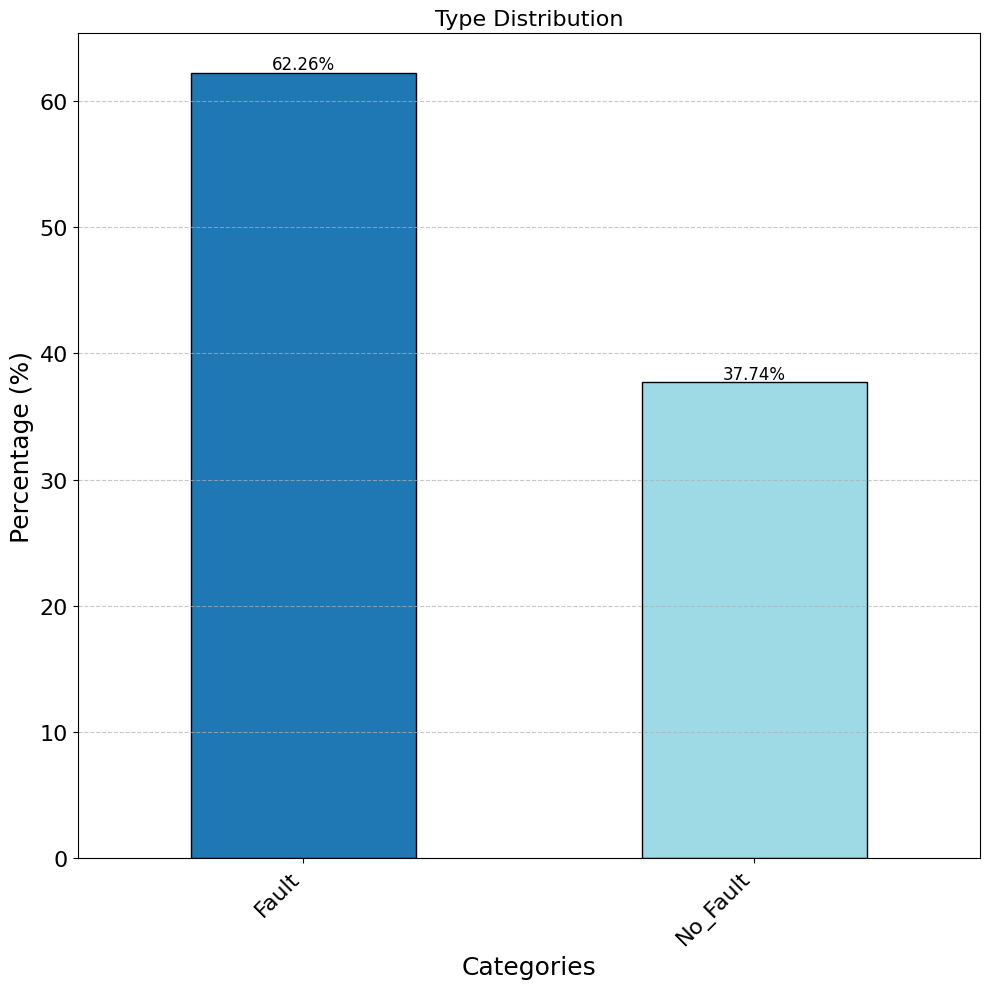

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        7.197733  1.515564  101.489258  144.726562  0.160277 -0.490112   
1        0.457292  1.458801  101.422119  144.140625  0.462401 -0.114136   
2        7.144096  1.551514  101.617432  143.847656 -0.309693  0.409546   
3        5.085500  1.766266   87.902832  143.554688 -0.470826  0.389404   
4        2.743520  1.582733  101.281738  143.554688  0.348266  0.053711   
...           ...       ...         ...         ...       ...       ...   
635362  10.633351  1.892090   87.988281  144.433594  0.334838 -0.530396   
635363  12.948130  2.595001    2.532959    1.171875  0.005858  0.006714   
635364   2.874451  2.260101   86.419678  148.242188  0.375121 -0.778809   
635365  12.965338  1.321625  102.294922  141.503906 -0.497682  0.382690   
635366  12.591919  2.447418   87.176514  145.605469  0.321410 -0.758667   

              ic          va          vb          vc      Iabc         If  \
0       0.289546  -61.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


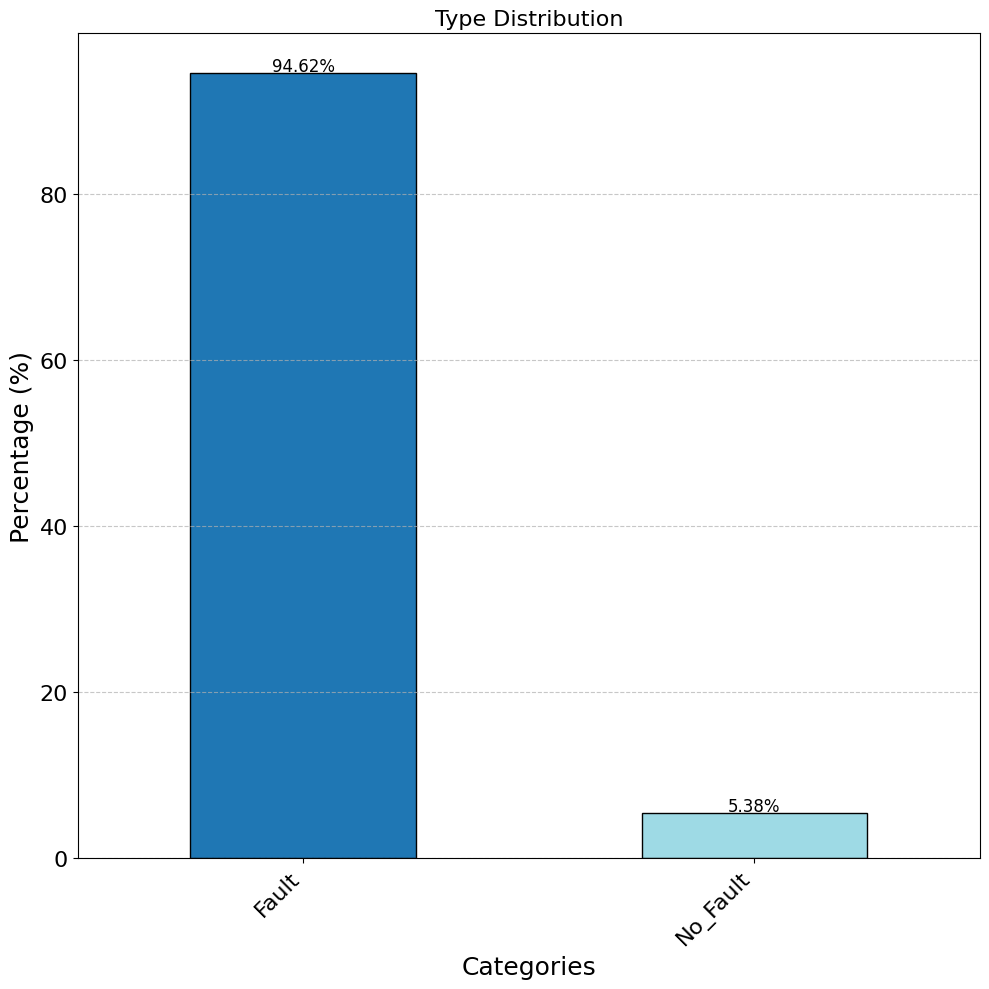

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        9.066308  1.817352   87.713623  144.726562 -0.524537  0.369263   
1       11.624463  2.584595    2.575684    1.171875  0.012572  0.006714   
2        0.473590  1.475830  100.695801  143.847656  0.274413 -0.496826   
3       11.688457  2.470123   85.028076  141.210938 -0.423829 -0.214844   
4       10.723168  1.535431  101.525879  142.089844  0.361693  0.026855   
...           ...       ...         ...         ...       ...       ...   
462284  10.453523  0.045410    1.300049  112.792969 -0.047853  0.046997   
462285  13.990273  2.454987   87.042236  146.777344 -0.047853 -0.657959   
462286   3.687565  2.207123   92.443848  149.121094  0.093139 -0.704956   
462287   6.591921  2.190094   90.722656  147.363281 -0.255982 -0.436401   
462288   6.079099  1.597870  100.878906  144.140625  0.314696 -0.543823   

              ic          va          vb          vc      Iabc         If  \
0       0.188838  155.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


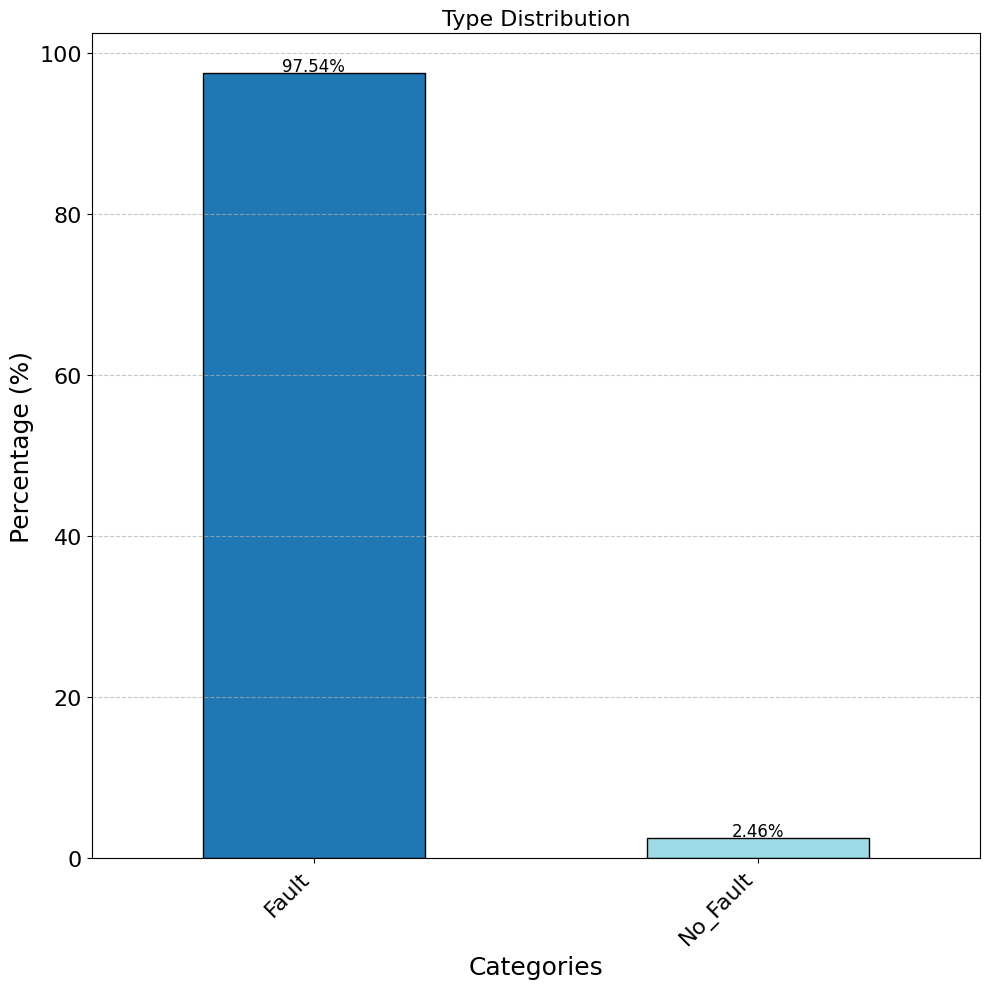

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        5.667904  2.256317   87.304688  149.121094 -0.544679 -0.100708   
1        6.654172  2.595001   84.790039  146.777344  0.569823 -0.617676   
2        6.081823  1.813568   74.938965  143.847656 -0.034425  0.449829   
3        8.280909  1.346222  101.580811  142.968750 -0.255982  0.436401   
4       10.609653  1.762482   88.208008  144.140625 -0.302979 -0.261841   
...           ...       ...         ...         ...       ...       ...   
319042   1.616721  1.453125  101.678467  145.019531  0.012572 -0.469971   
319043   7.421240  1.941284   75.018311  143.261719  0.005858  0.355835   
319044   2.375002  2.489990   86.822510  147.363281  0.422118 -0.691528   
319045   0.571495  2.314026   86.694336  147.949219 -0.249269 -0.463257   
319046   2.963840  2.117249   92.437744  149.414062 -0.517823  0.020142   

              ic          va          vb          vc      Iabc         If  \
0       0.631953  110.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


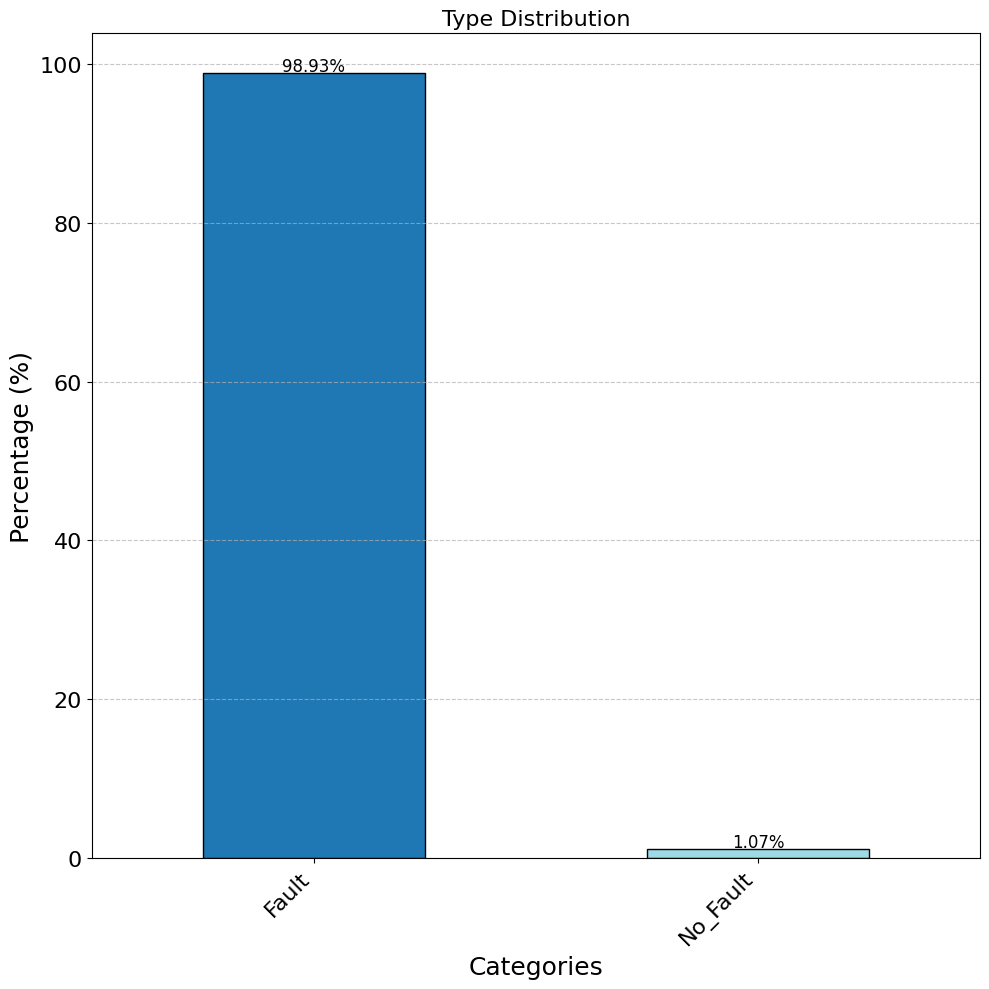

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        8.362701  1.582733  101.348877  143.261719 -0.437257  0.355835   
1        1.368315  2.493774   86.822510  146.777344 -0.685670  0.187988   
2        5.198128  2.368896   86.743164  147.070312  0.690673 -0.268555   
3        4.080308  2.231720   88.281250  146.191406  0.529540  0.046997   
4        5.207694  1.533539  101.245117  143.554688 -0.269410 -0.228271   
...           ...       ...         ...         ...       ...       ...   
109805  11.247944  0.057709  108.831787  114.257812  0.079711 -0.060425   
109806   4.772019  1.497589  101.458740  144.140625  0.294555 -0.516968   
109807   5.053319  2.358490   88.275146  146.777344 -0.141847 -0.530396   
109808   2.970632  1.477722  100.958252  143.554688  0.200561 -0.523682   
109809   3.986534  2.176849   92.437744  149.121094 -0.168702 -0.537109   

              ic          va          vb          vc      Iabc         If  \
0       0.047847  129.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


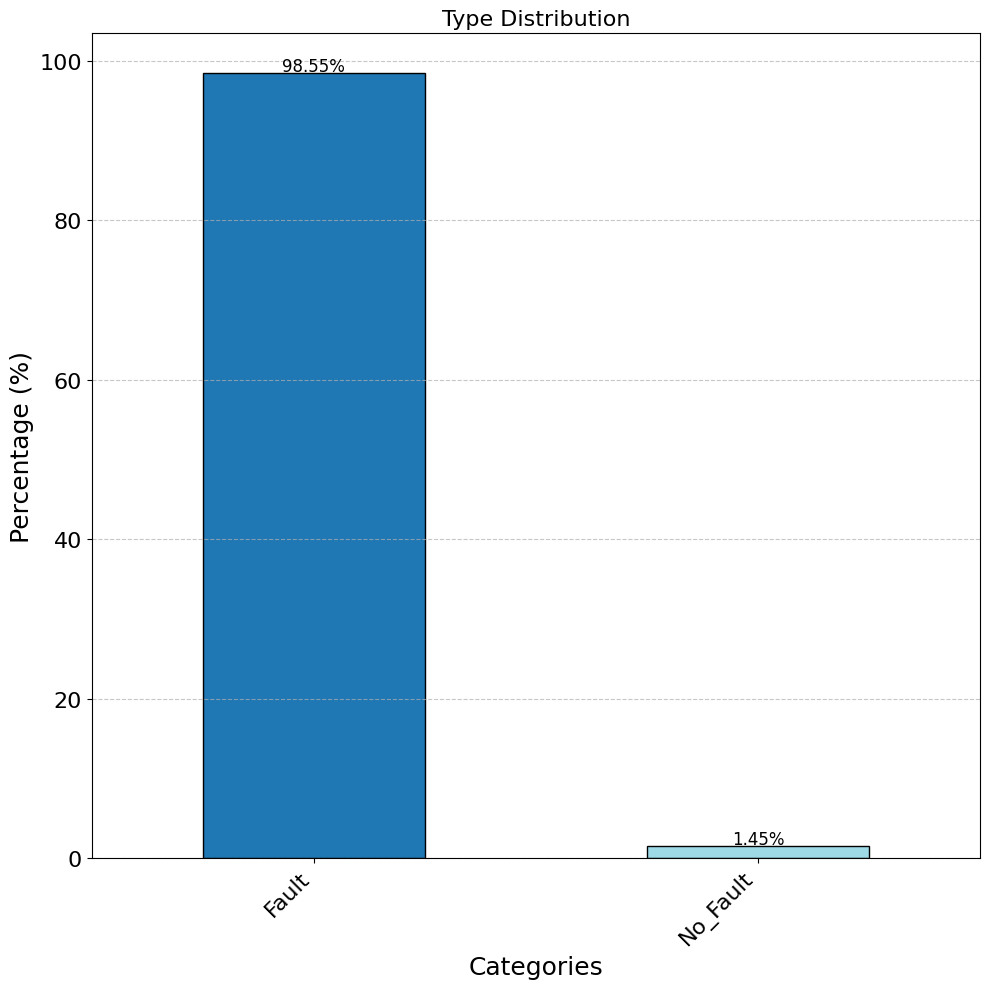

In [ ]:
i=0
for df in smaller_dfs:
 print(df)
 i=i+1
 df.describe()
 df['FaultType']=df['FaultType'].map(Inverse_Fault_map)
 plot_bar_chart(df)
 #plot_bar_chart2(df,'Fault Distribution for Client N°:'+str(i))

             Time       Ipv         Vpv         Vdc        ia        ib  \
0       13.832041  2.234558    4.608154    4.101562 -0.027711  0.033569   
1       11.142359  1.348114  102.239990  142.089844 -0.061280  0.140991   
2        2.372243  1.363251  101.892090  144.433594 -0.450685  0.167847   
3        6.391098  1.392578  100.628662  143.847656 -0.195558 -0.328979   
4       13.698160  1.383118  101.666260  141.210938  0.247558 -0.496826   
...           ...       ...         ...         ...       ...       ...   
326275  10.899983  1.406769  101.684570  141.210938 -0.323121  0.154419   
326276  11.749820  1.455017  101.489258  145.605469  0.012572 -0.429688   
326277  11.925033  2.563782    2.557373    1.171875  0.012572  0.006714   
326278   4.173278  1.284729  101.641846  144.433594 -0.020997  0.382690   
326279   1.148144  1.422852  101.776123  144.140625  0.442260 -0.174561   

              ic          va          vb          vc      Iabc         If  \
0       0.007563   79.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


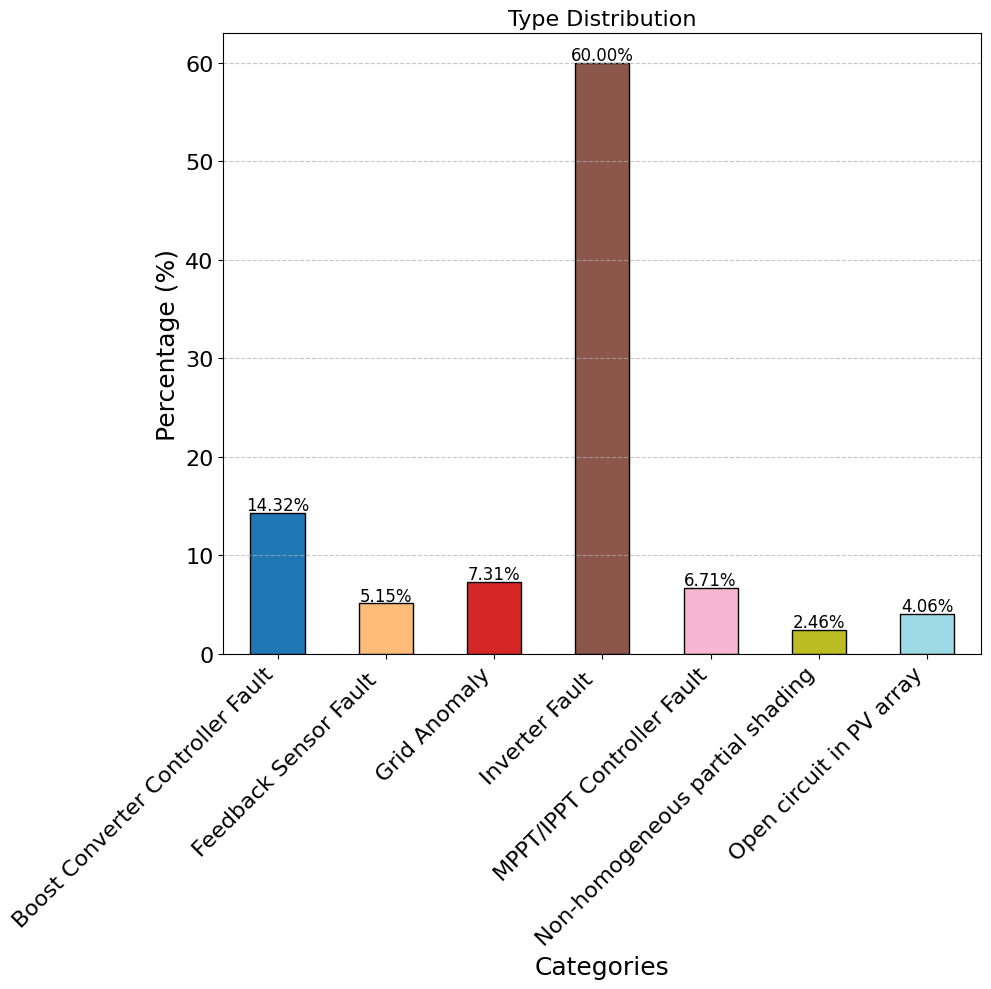

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        1.643375  2.324432   86.010742  148.535156 -0.504396  0.725098   
1        6.209216  2.258209   86.212158  147.363281 -0.437257 -0.275269   
2        1.916432  2.479584   87.115479  148.242188  0.650390 -0.181274   
3        4.896155  1.591248  101.379395  142.968750  0.448974 -0.315552   
4       14.084264  2.474854   86.462402  146.191406 -0.705812  0.490112   
...           ...       ...         ...         ...       ...       ...   
326275   2.954738  2.307404   84.753418  148.535156  0.657104 -0.557251   
326276   4.178873  1.437042  101.348877  144.140625  0.059569  0.362549   
326277   4.549283  2.610138   85.089111  147.070312 -0.376832 -0.302124   
326278  10.125001  1.433258  101.574707  140.332031 -0.544679  0.443115   
326279  13.573489  1.402985  101.641846  135.937500  0.072997 -0.543823   

              ic          va          vb          vc      Iabc         If  \
0      -0.247563  104.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


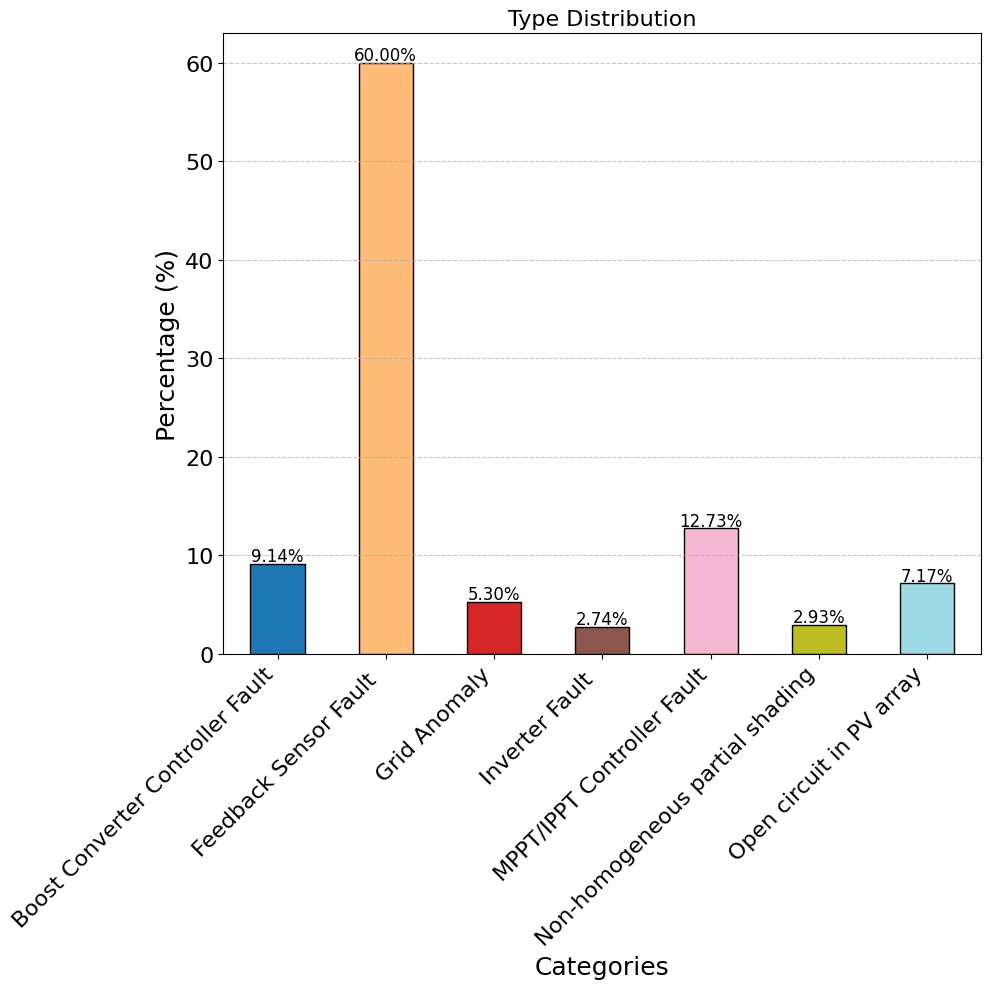

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        3.502733  1.904388   75.671387  144.433594 -0.182130  0.490112   
1       12.239602  2.549591   84.417725  143.554688  0.234130 -0.208130   
2        3.168827  1.519348  100.402832  144.433594 -0.464112  0.046997   
3        4.907353  1.546783  101.385498  144.140625 -0.511109  0.255127   
4        3.126982  1.379333  101.123047  144.140625 -0.121705  0.463257   
...           ...       ...         ...         ...       ...       ...   
292297   7.147408  2.352814   88.330078  147.070312 -0.598390  0.577393   
292298   3.457792  2.289429   86.859131  147.070312  0.657104 -0.382690   
292299   0.610198  1.430420  102.014160  143.554688  0.301269  0.107422   
292300   4.361289  1.400146  102.032471  144.140625  0.019286  0.362549   
292301  11.222416  2.575134    2.532959    1.171875  0.012572  0.006714   

              ic          va          vb          vc      Iabc         If  \
0      -0.294561   58.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


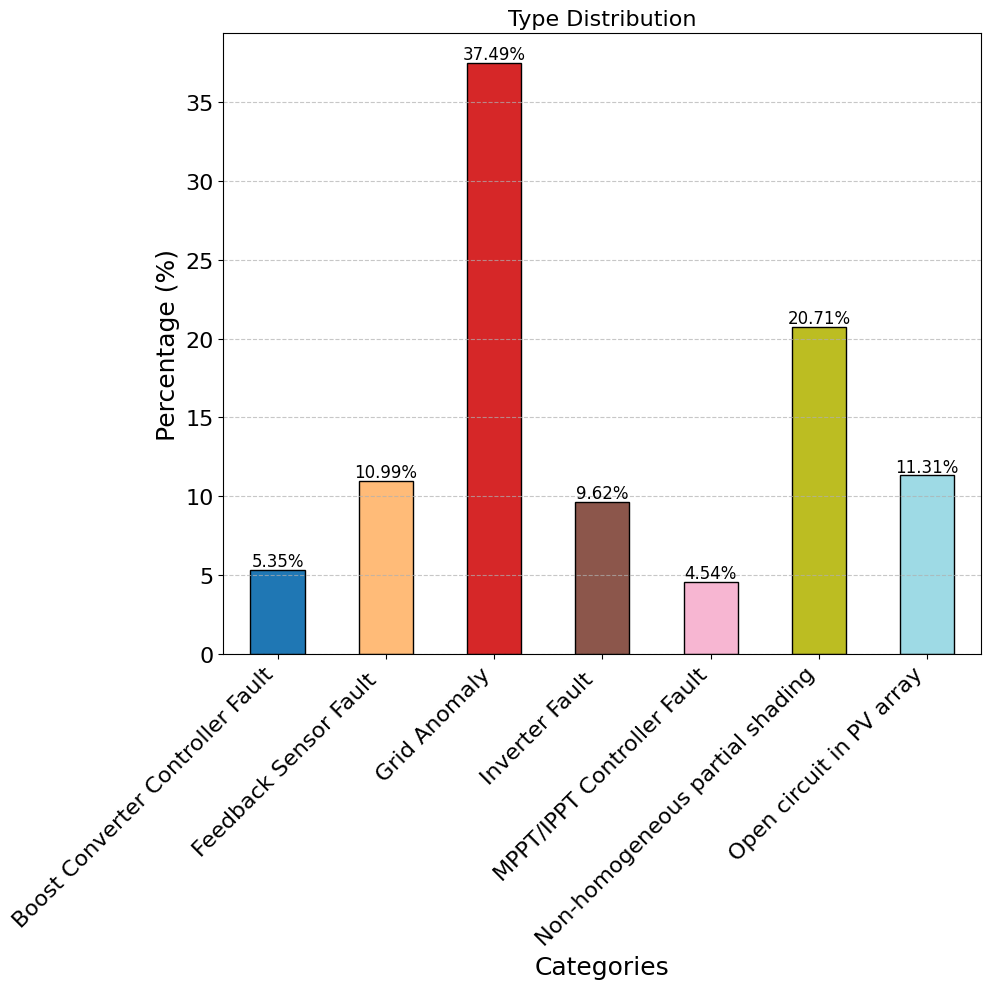

             Time       Ipv         Vpv         Vdc        ia        ib  \
0        1.296783  1.819244   87.609863  145.898438  0.469115 -0.140991   
1       11.955418  1.813568   87.609863  144.433594  0.529540 -0.389404   
2        0.473105  2.479584   86.029053  148.242188  0.072997 -0.718384   
3       12.809608  2.050079   74.304199  143.261719 -0.262696 -0.120850   
4       12.801808  2.033997   74.871826  142.968750 -0.047853  0.396118   
...           ...       ...         ...         ...       ...       ...   
264659   8.171798  1.947906   87.536621  143.847656  0.086425 -0.429688   
264660   2.819693  1.496643  101.562500  143.847656  0.442260 -0.483398   
264661   1.886323  1.876007   87.872314  144.433594 -0.497682  0.302124   
264662   6.373873  1.797485   88.323975  143.847656  0.408690 -0.483398   
264663   7.764346  2.077515   74.188232  144.433594 -0.376832  0.456543   

              ic          va          vb          vc      Iabc         If  \
0      -0.428838 -151.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


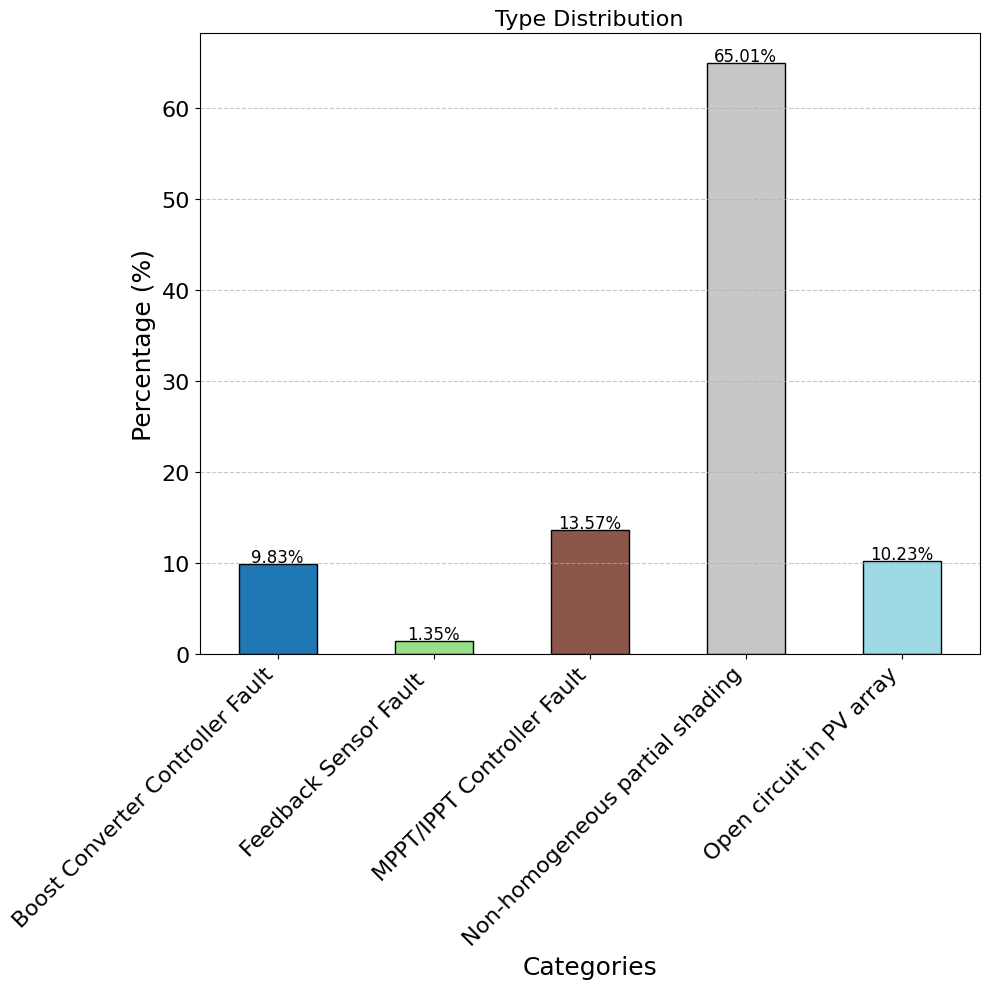

             Time       Ipv         Vpv         Vdc        ia        ib  \
0       11.088060  0.048248  108.728027  114.843750  0.079711 -0.073853   
1       10.721097  0.067169  108.496094  116.015625 -0.054566 -0.114136   
2        8.617307  0.031219    1.428223  117.187500 -0.135133  0.067139   
3        1.249378  1.507996  101.275635  144.726562 -0.370118  0.449829   
4        7.169078 -0.015137   96.185303  132.421875 -0.081422 -0.006714   
...           ...       ...         ...         ...       ...       ...   
221519   0.240696  1.525970  101.483154  144.433594  0.475829 -0.328979   
221520   8.729995  0.046356    1.556396  116.601562  0.113280 -0.013428   
221521   9.793011  0.033112    1.403809  114.843750  0.079711  0.040283   
221522   2.180177  1.455017  101.251221  144.433594  0.522826 -0.490112   
221523   3.320463  1.447449  101.843262  144.140625  0.475829 -0.389404   

              ic          va          vb          vc      Iabc         If  \
0      -0.086431  156.

<ipython-input-134-97ab546c52ba>:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(all_categories))  # Use 'tab20' for diverse colors


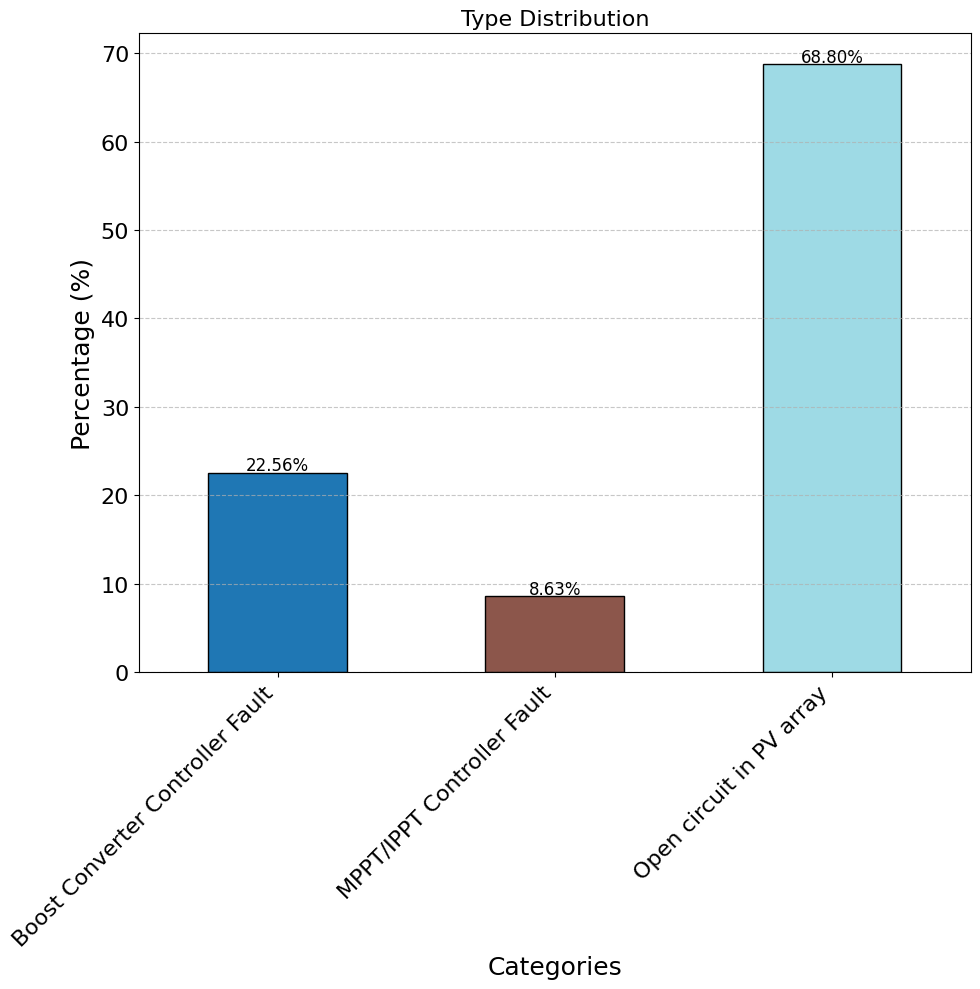

In [ ]:
i=0
for df in smaller_dfs2:
 print(df)
 i=i+1
 df.describe()
 df['FaultType']=df['FaultType'].map(multi_faults)
 plot_bar_chart(df)
 #plot_bar_chart2(df,'Fault Distribution for Client N°:'+str(i))

In [ ]:
# # Faults detection
# aggregation_types=['geometric_median' ,'mean','median']
# # for i in range(2,6):
# num_clients =6
# nrounds=20
# architectureB=(87,87)
# max_iterB=100
# random_stateB=42
# learning_rate_typeB='adaptive'
# client_data=dfBinaryfully
# # .sample(n=2000000, random_state=42)
# # X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=20000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# accuracies, precisions, recalls, f1_scores=runFLSolution(aggregation_types, architectureB,max_iterB,random_stateB,learning_rate_typeB, client_data, num_clients,feature_names,target_column='FaultType',nrounds=nrounds,i=1)

In [ ]:
dfmultiFaultfully.FaultType.unique()

array([4, 6, 1, 2, 7, 3, 5])

In [ ]:
# # Faults diagnostic
# aggregation_types=['geometric_median' ,'mean','median']
# # for i in range(2,6):
# num_clients =5
# nrounds=12
# architectureB=(60,60,60)
# max_iterB=100
# random_stateB=42
# learning_rate_typeB='adaptive'
# client_data=dfmultiFaultfully
# # .sample(n=2000000, random_state=42)
# # X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=20000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
# accuracies, precisions, recalls, f1_scores=runFLSolution(aggregation_types, architectureB,max_iterB,random_stateB,learning_rate_typeB, client_data, num_clients,feature_names,target_column='FaultType',nrounds=nrounds,i=2)

**Sensitivity**

In [ ]:
# Faults detection
aggregation_types=['geometric_median' ,'mean','median']
for i in range(4,6):
 num_clients =i
 print('Number Of Client:',i)
 nrounds=12
 architectureB=(87,87)
 max_iterB=100
 random_stateB=42
 learning_rate_typeB='adaptive'
 client_data=dfBinaryfully
 # .sample(n=2000000, random_state=42)
 # X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=20000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
 accuracies, precisions, recalls, f1_scores=runFLSolution(aggregation_types, architectureB,max_iterB,random_stateB,learning_rate_typeB, client_data, num_clients,feature_names,target_column='FaultType',nrounds=nrounds,i=2)

Number Of Client: 4
Running federated learning with geometric_median aggregation...
Round 1/12
Metric Accuracy: 1.0
Round 2/12
Metric Accuracy: 1.0
Round 3/12
Metric Accuracy: 1.0
Round 4/12
Metric Accuracy: 1.0
Round 5/12
Metric Accuracy: 1.0
Round 6/12
Metric Accuracy: 1.0
Round 7/12
Metric Accuracy: 1.0
Round 8/12
Metric Accuracy: 1.0
Round 9/12
Metric Accuracy: 1.0
Round 10/12
Metric Accuracy: 1.0
Round 11/12
Metric Accuracy: 1.0
Round 12/12
Metric Accuracy: 1.0
Running federated learning with mean aggregation...
Round 1/12
Metric Accuracy: 1.0
Round 2/12
Metric Accuracy: 1.0
Round 3/12
Metric Accuracy: 1.0
Round 4/12
Metric Accuracy: 1.0
Round 5/12
Metric Accuracy: 1.0
Round 6/12
Metric Accuracy: 1.0
Round 7/12
Metric Accuracy: 1.0
Round 8/12
Metric Accuracy: 1.0
Round 9/12
Metric Accuracy: 1.0
Round 10/12
Metric Accuracy: 1.0
Round 11/12
Metric Accuracy: 1.0
Round 12/12
Metric Accuracy: 1.0
Running federated learning with median aggregation...
Round 1/12
Metric Accuracy: 1.0
Roun

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Metric Accuracy: 1.0
Round 6/12
Metric Accuracy: 1.0
Round 7/12
Metric Accuracy: 1.0
Round 8/12
Metric Accuracy: 1.0
Round 9/12
Metric Accuracy: 1.0
Round 10/12
Metric Accuracy: 1.0
Round 11/12
Metric Accuracy: 1.0
Round 12/12
Metric Accuracy: 1.0
Running federated learning with median aggregation...
Round 1/12
Metric Accuracy: 1.0
Round 2/12
Metric Accuracy: 1.0
Round 3/12
Metric Accuracy: 1.0
Round 4/12
Metric Accuracy: 1.0
Round 5/12
Metric Accuracy: 1.0
Round 6/12
Metric Accuracy: 1.0
Round 7/12
Metric Accuracy: 1.0
Round 8/12
Metric Accuracy: 1.0
Round 9/12
Metric Accuracy: 1.0
Round 10/12
Metric Accuracy: 1.0
Round 11/12
Metric Accuracy: 1.0
Round 12/12
Metric Accuracy: 1.0


In [ ]:
# Faults diagnostic
aggregation_types=['geometric_median' ,'mean','median']
for i in range(2,6):
 num_clients =i
 print('Number Of Client:',i)
 nrounds=12
 architectureB=(60,60,60)
 max_iterB=100
 random_stateB=42
 learning_rate_typeB='adaptive'
 client_data=dfmultiFaultfully
 # .sample(n=2000000, random_state=42)
 # X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=20000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
 accuracies, precisions, recalls, f1_scores=runFLSolution(aggregation_types, architectureB,max_iterB,random_stateB,learning_rate_typeB, client_data, num_clients,feature_names,target_column='FaultType',nrounds=nrounds,i=2)

Number Of Client: 2


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Running federated learning with geometric_median aggregation...
Round 1/12
Metric Accuracy: 0.9859544249179738
Round 2/12
Metric Accuracy: 0.984111645467212
Round 3/12
Metric Accuracy: 0.9847858330711493
Round 4/12
Metric Accuracy: 0.9844487392691806
Round 5/12
Metric Accuracy: 0.9857971144770552
Round 6/12
Metric Accuracy: 0.9851453997932491
Round 7/12
Metric Accuracy: 0.986156681199155
Round 8/12
Metric Accuracy: 0.9852352914737741
Round 9/12
Metric Accuracy: 0.9854375477549553
Round 10/12
Metric Accuracy: 0.9859993707582363
Round 11/12
Metric Accuracy: 0.9855274394354803
Round 12/12
Metric Accuracy: 0.9864488291608612
Running federated learning with mean aggregation...
Round 1/12
Metric Accuracy: 0.9854375477549553
Round 2/12
Metric Accuracy: 0.9842464829879994
Round 3/12
Metric Accuracy: 0.9855274394354803
Round 4/12
Metric Accuracy: 0.9850555081127241
Round 5/12
Metric Accuracy: 0.9851004539529866
Round 6/12
Metric Accuracy: 0.9845161580295744
Round 7/12
Metric Accuracy: 0.9861566

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Running federated learning with geometric_median aggregation...
Round 1/12
Metric Accuracy: 0.9868341320993775
Round 2/12
Metric Accuracy: 0.9860353660551975
Round 3/12
Metric Accuracy: 0.9858976477717182
Round 4/12
Metric Accuracy: 0.9858425604583264
Round 5/12
Metric Accuracy: 0.985346774637801
Round 6/12
Metric Accuracy: 0.9850988817275381
Round 7/12
Metric Accuracy: 0.9847959015038836
Round 8/12
Metric Accuracy: 0.9870820250096403
Round 9/12
Metric Accuracy: 0.9862557153087644
Round 10/12
Metric Accuracy: 0.9854294056078885
Round 11/12
Metric Accuracy: 0.986531151875723
Round 12/12
Metric Accuracy: 0.984906076130667
Running federated learning with mean aggregation...
Round 1/12
Metric Accuracy: 0.9892028865752217
Round 2/12
Metric Accuracy: 0.9869167630694651
Round 3/12
Metric Accuracy: 0.9871921996364237
Round 4/12
Metric Accuracy: 0.985346774637801
Round 5/12
Metric Accuracy: 0.9877981600837327
Round 6/12
Metric Accuracy: 0.9856772985181512
Round 7/12
Metric Accuracy: 0.987798160

...

Metric Accuracy: 0.984444655221474
Round 2/12
Metric Accuracy: 0.9831167599355022
Round 3/12
Metric Accuracy: 0.986114009295267
Round 4/12
Metric Accuracy: 0.985601821113535
Round 5/12
Metric Accuracy: 0.9849758133358627
Round 6/12
Metric Accuracy: 0.9866451674096557
Round 7/12
Metric Accuracy: 0.9865123778810585
Round 8/12
Metric Accuracy: 0.9854500616522811
Round 9/12
Metric Accuracy: 0.9859812197666699
Round 10/12
Metric Accuracy: 0.9864934079484018
Round 11/12
Metric Accuracy: 0.9854310917196244
Round 12/12
Metric Accuracy: 0.985962249834013
Running federated learning with mean aggregation...
Round 1/12
Metric Accuracy: 0.9855069714502513
Round 2/12


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Metric Accuracy: 0.9854310917196244
Round 3/12


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:697: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


KeyboardInterrupt: 

In [ ]:
# Naive
aggregation_types=['geometric_median' ,'mean','median']
num_clients =6
nrounds=20
architectureB=(69,69,69)
max_iterB=10000
random_stateB=42
learning_rate_typeB='adaptive'
client_data=dfnaivefully
# .sample(n=2000000, random_state=42)
# X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=20000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')
accuracies, precisions, recalls, f1_scores=runFLSolution(aggregation_types, architectureB,max_iterB,random_stateB,learning_rate_typeB, client_data, num_clients,feature_names,target_column='FaultType',nrounds=nrounds)

TypeError: runFLSolution() missing 1 required positional argument: 'i'

In [ ]:
#   #  To convert label to categories (visualiztion results)
# Inversefault_map = { 0:"No-Fault", 1: "Fault"}

# dfBinaryfully["FaultType"] = dfBinaryfully["FaultType"].map(Inversefault_map)
# print(dfBinaryfully["FaultType"].unique())
# print(dfBinaryfully['FaultType'].value_counts())


# multi_faults = {   1: 'Inverter Fault ', 2:'Feedback Sensor Fault ',3:'Grid Anomaly',4:'Non-homogeneous partial shading',
#       5:'Open circuit in PV array',6:'MPPT/IPPT Controller Fault',7:'Boost Converter Controller Fault'}
# dfmultiFaultfully["FaultType"] =dfmultiFaultfully["FaultType"].map(multi_faults)
# print(dfmultiFaultfully["FaultType"].unique())
# print(dfmultiFaultfully['FaultType'].value_counts())


# faults = { 0:"No-Fault",   1: 'Inverter Fault ', 2:'Feedback Sensor Fault ',3:'Grid Anomaly',4:'Non-homogeneous partial shading',
#       5:'Open circuit in PV array',6:'MPPT/IPPT Controller Fault',7:'Boost Converter Controller Fault'}
# dfnaivefully["FaultType"]= dfnaivefully["FaultType"].map(faults)
# print(dfnaivefully["FaultType"].unique())
# print(dfnaivefully['FaultType'].value_counts())
fault_labels = [
    'No-Fault',
    'Inverter Fault ',
    'Feedback Sensor Fault ',
    'Grid Anomaly',
    'Non-homogeneous partial shading',   # PV Array Mismatch (10 to 20% nonhomogeneous partial shading)
    'Open circuit in PV array',#PV Array Mismatch (15% open circuit in PV array)
    'MPPT/IPPT Controller Fault',
    'Boost Converter Controller Fault'
]
fault_map = {"No-Fault": 0, "Fault": 1}
multiFaultsList =  ['Inverter Fault ',
    'Feedback Sensor Fault ',
    'Grid Anomaly',
    'Non-homogeneous partial shading',   # PV Array Mismatch (10 to 20% nonhomogeneous partial shading)
    'Open circuit in PV array',#PV Array Mismatch (15% open circuit in PV array)
    'MPPT/IPPT Controller Fault',
    'Boost Converter Controller Fault'
]

fault_list = ["No-Fault", "Fault"]

In [ ]:
print("Reading the DataFrame...")
df_finalfully,df_final= readingDataFrame()
# df_finalfully= pd.get_dummies(df_finalfully, columns=['Mode'])
df_final = pd.get_dummies(df_final, columns=['Mode'])
df_final=df_final[df_final.columns[:-1]]
df_finalfully = pd.get_dummies(df_finalfully, columns=['Mode'])

df_finalfully=df_finalfully[df_finalfully.columns[:-1]]

# dfnaive,dfBinary,dfmultiFault=constructDatasets(df_final)
print("Constructing datasets...")
dfnaivefully,dfBinaryfully,dfmultiFaultfully=construct_datasets(df_final)
# df_finalfully

# dfnaive.drop('Time', axis=1, inplace=True)
# dfBinary.drop('Time', axis=1, inpmodel_classificationlace=True)
# dfmultiFault.drop('Time', axis=1, inplace=True)

dfnaivefully.drop('Time', axis=1, inplace=True)
dfBinaryfully.drop('Time', axis=1, inplace=True)
dfmultiFaultfully.drop('Time', axis=1, inplace=True)

feature_names=list(dfnaivefully.columns[:-1])
feature_names.remove('FaultType')

print("Dividing the DataFrame...")
X_train, X_test, y_train, y_test=process_and_split_dataframe(dfBinaryfully.sample(n=10000, random_state=42) ,feature_names, target_column='FaultType',  test_size=0.2, random_state=42,scaling=True,scaling_type='standard')


parametre = {'activation': 'tanh', 'hidden_layer_sizes': (18,18), 'learning_rate': 'adaptive', 'learning_rate_init': 0.037596750372928894, 'max_iter': 9000, 'solver': 'lbfgs'}
print('Model is being trained')
mlp_classifier = MLPClassifier(**parametre ,verbose=False)

print(mlp_classifier.get_params())

mlp_classifier.fit(X_train, y_train)
print('Model is being predicted')


y_pred = mlp_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Test Accuracy: {accuracy:.3f}, Test F1: {f1:.3f}, Test Precision: {precision:.3f}, Test Recall: {recall:.3f}")

data = pd.DataFrame({"Test Accuracy": [accuracy], "Test F1": [f1], "Test Precision": [precision], "Test Recall": [recall]})


data.to_csv('/content/drive/MyDrive/data_model.csv', index=False)




Reading the DataFrame...
Constructing datasets...
Unique values in df_binary['FaultType']: [1 0]


<ipython-input-7-2800ef9250cb>:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_multi_fault = df_multi_fault[df_final['FaultType'] > 0]


Unique values in df_multi_fault['FaultType']: [4 6 1 2 7 3 0 5]
Dividing the DataFrame...
Model is being trained
{'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (18, 18), 'learning_rate': 'adaptive', 'learning_rate_init': 0.037596750372928894, 'max_fun': 15000, 'max_iter': 9000, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': None, 'shuffle': True, 'solver': 'lbfgs', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
Model is being predicted
Test Accuracy: 0.960, Test F1: 0.960, Test Precision: 0.960, Test Recall: 0.960


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import ShuffleSplit, learning_curve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def initialize_global_modelRF(n_estimators, max_depth, random_state, client_data):
    """Initialize and fit the global Random Forest model."""
    global_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        warm_start=True
    )
    X_train, y_train = client_data[0]  # Use the first client to fit
    global_model.fit(X_train, y_train)  # Initial fit to ensure initialization
    return global_model


# Function to create and initialize a local model
def create_local_modelRF(global_model):
    """Create a local model with the same structure as the global model."""
    local_model = RandomForestClassifier(
        n_estimators=global_model.n_estimators,
        max_depth=global_model.max_depth,
        random_state=global_model.random_state,
        warm_start=True
    )
    local_model.set_params(**global_model.get_params())  # Copy parameters
    return local_model


# Function for local training and returning the fitted model
def local_trainingRF(local_model, X_train, y_train):
    """Train a local Random Forest model and return the fitted model."""
    local_model.fit(X_train, y_train)
    return local_model


# Function for federated learning with proper aggregation and metrics calculation
def federated_learningRF(num_rounds, client_data, client_datatest, global_model, aggregation_method, i):
    """Simulate federated learning with multiple rounds and calculate various metrics."""
    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []

    if i == 1:
        labels = ["No-Fault", "Fault"]
    else:
        labels = [
            'Inverter Fault',
            'Feedback Sensor Fault',
            'Grid Anomaly',
            'Non-homogeneous partial shading',
            'Open circuit in PV array',
            'MPPT/IPPT Controller Fault',
            'Boost Converter Controller Fault'
        ]

    for round_num in range(num_rounds):
        client_models = []

        # Local training for each client
        for X_train, y_train in client_data:
            local_model = create_local_model(global_model)
            local_model = local_training(local_model, X_train, y_train)
            client_models.append(local_model)

        # Aggregate feature importances (as a proxy for parameter aggregation)
        feature_importances = np.array([model.feature_importances_ for model in client_models])
        aggregated_importances = aggregation_method(feature_importances)

        # Update the global model with new feature importances
        global_model.feature_importances_ = aggregated_importances

        # Metrics calculation
        round_accuracies = []
        round_precisions = []
        round_recalls = []
        round_f1_scores = []

        for X_test, y_test in client_datatest:
            predictions = global_model.predict(X_test)
            accuracy = accuracy_score(y_test, predictions)
            precision = precision_score(y_test, predictions, average='weighted')
            recall = recall_score(y_test, predictions, average='weighted')
            f1 = f1_score(y_test, predictions, average='weighted')

            # Confusion Matrix
            conf_matrix = confusion_matrix(y_test, predictions, normalize='true')
            cm_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

            plt.figure(figsize=(6, 6))
            sns.heatmap(cm_df, annot=True, cmap="Blues", fmt=".3f", xticklabels=labels, yticklabels=labels)
            plt.title('Confusion Matrix')
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.show()

            # Store metrics
            round_accuracies.append(accuracy)
            round_precisions.append(precision)
            round_recalls.append(recall)
            round_f1_scores.append(f1)

        # Calculate mean metrics for the round
        accuracies.append(np.mean(round_accuracies))
        precisions.append(np.mean(round_precisions))
        recalls.append(np.mean(round_recalls))
        f1_scores.append(np.mean(round_f1_scores))

    return accuracies, precisions, recalls, f1_scores


# Aggregation function
def perform_federated_learningRF(nrounds, client_data, client_datatest, global_model, aggregation_type, i):
    """Perform federated learning with specified aggregation type."""
    if aggregation_type.lower() == 'mean':
        aggregation_method = lambda x: np.mean(x, axis=0)
    elif aggregation_type.lower() == 'median':
        aggregation_method = lambda x: np.median(x, axis=0)
    else:
        raise ValueError("Invalid aggregation type. Use 'mean' or 'median'.")

    accuracies, precisions, recalls, f1_scores = federated_learning(
        nrounds, client_data, client_datatest, global_model, aggregation_method, i
    )

    return accuracies, precisions, recalls, f1_scores
